# Purchase Behaviour Based Customer Segmentation Using CART - Based Machine Learning



## Team Members

The team for this project consists of the following members:

Gratus Richard Anthuvan Rosario - 20700451
Fahad M Mujawar - 20711746
Sachin Joseph Fernando - 20713999

Each member contributed to various parts of the project, working collaboratively to ensure the final outcome.



## Overview
This project focuses on analyzing customer behavior and segmenting households based on their purchasing patterns, demographics, and responses to marketing campaigns. The dataset comes from Dunnhumby, a customer science company, and includes transaction data, product details, coupon redemptions, and household demographics.




## Processing Time

**In this notebook, we are working with a large dataset, which may result in some cells taking up to 5 minutes to run.**

> *We've implemented several strategies to ensure that the processing is as memory-efficient as possible, such as using chunking when loading data and optimizing data transformations.*

**Thank you for your understanding while the notebook processes the data!**


## Data Source
  [Dataset: Dunnhumby - The Complete Journey](https://www.kaggle.com/datasets/frtgnn/dunnhumby-the-complete-journey)


## Data Sources
The dataset consists of 8 primary tables:
- `transactions`: Customer purchase records
- `product`: Product details and categories
- `coupon`: Coupon information
- `hh_demographic`: Household characteristics
- `campaign_table`: Marketing campaign assignments
- `causal_data`: Product display and promotion data
- `campaign_desc`: Campaign descriptions
- `coupon_redempt`: Coupon redemption records

## Key Metrics Calculated
- **Average Transaction Value (ATV)**: Mean spending per transaction
- **Average Basket Size (ABS)**: Average number of unique products per transaction
- **Average Price Point (APP)**: Mean price per item purchased
- **Repeat Households and their purchase metrics**
- **Visit Latency**: Days between subsequent visits for repeat customers
- **Campaign Response Rate**: Percentage of coupons redeemed

## How to Use This Notebook
1. Run cells sequentially to reproduce the analysis
2. Intermediate tables are exported as CSV files for inspection
3. Final outputs include comprehensive household behavior profiles

## Dependencies
- Python 3.x
- pandas
- sqlalchemy
- matplotlib
- seaborn
- scikit-learn
- tqdm
- gdown (for data download)




# 1. Data Ingestion
#### We ingest the data, study the table counts and NULLs in the tables and then establish a relevant ERD for the 8 tables.

In [3]:
!pip install gdown

In [4]:
#improting libraries

import os
import shutil
from zipfile import ZipFile
import pandas as pd
import sqlite3
import pandas as pd
from tqdm import tqdm
import gdown
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt
import seaborn as sns
import random

In [5]:
#Setting up random Seed


SEED = 42

# Python built-in random
random.seed(SEED)

# NumPy
np.random.seed(SEED)

#### Cleaning Up Local Directory (Excluding Notebooks)

This section deletes all files and directories except Jupyter notebooks.  
`shutil` is used for removing directories, while `os.remove` handles files. No additional error handling or logging is implemented here for simplicity.  


In [7]:
cwd = os.getcwd()

for item in os.listdir(cwd):
    full_path = os.path.join(cwd, item)

    if item.endswith(".ipynb"):
        continue

    if os.path.isdir(full_path):
        shutil.rmtree(full_path)

    # Delete other files
    elif os.path.isfile(full_path):
        os.remove(full_path)

#### Downloading File from Google Drive

This code downloads a file from Google Drive using the `gdown` library. The file is downloaded as `archive.zip`.  



In [9]:

file_id = "11Z3ugHbbQFE-_mosH7i-SQX1T3vyXIne"
gdown.download(f"https://drive.google.com/uc?id={file_id}", output="archive.zip", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=11Z3ugHbbQFE-_mosH7i-SQX1T3vyXIne
From (redirected): https://drive.google.com/uc?id=11Z3ugHbbQFE-_mosH7i-SQX1T3vyXIne&confirm=t&uuid=cc8507a2-a03f-482c-97bf-10dc34486f51
To: C:\Users\sachi\Downloads\DSML Dry run\archive.zip
100%|██████████| 135M/135M [00:30<00:00, 4.47MB/s] 


'archive.zip'

In [10]:
#import the archive.zip file before running

zip = ZipFile('archive.zip')
zip.extractall()

from zipfile import ZipFile
import os
import shutil

with ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('temp_extracted')

extracted_path = 'temp_extracted'
inner_items = os.listdir(extracted_path)

if len(inner_items) == 1 and os.path.isdir(os.path.join(extracted_path, inner_items[0])):
    inner_folder = os.path.join(extracted_path, inner_items[0])
    for item in os.listdir(inner_folder):
        shutil.move(os.path.join(inner_folder, item), '.')
else:
    for item in inner_items:
        shutil.move(os.path.join(extracted_path, item), '.')

# Clean up
shutil.rmtree(extracted_path)

In [11]:
'''
Loads each Dunnhumby CSV table into pandas DataFrames using the same filenames
as your ingestion code, then exports the top 1,000 rows from each table
for schema inspection.
'''

DATA_DIR = r"./"
SAMPLE_DIR = os.path.join(os.path.dirname(DATA_DIR), 'samples')
os.makedirs(SAMPLE_DIR, exist_ok=True)

# Load Tables

transactions_df     = pd.read_csv(os.path.join(DATA_DIR, 'transaction_data.csv'))
product_df          = pd.read_csv(os.path.join(DATA_DIR, 'product.csv'))
coupon_df           = pd.read_csv(os.path.join(DATA_DIR, 'coupon.csv'))
hh_demographic_df   = pd.read_csv(os.path.join(DATA_DIR, 'hh_demographic.csv'))
campaign_table_df   = pd.read_csv(os.path.join(DATA_DIR, 'campaign_table.csv'))
causal_data_df      = pd.read_csv(os.path.join(DATA_DIR, 'causal_data.csv'))
campaign_desc_df    = pd.read_csv(os.path.join(DATA_DIR, 'campaign_desc.csv'))
coupon_redempt_df   = pd.read_csv(os.path.join(DATA_DIR, 'coupon_redempt.csv'))



In [12]:
# Sampling and Export
SAMPLE_SIZE = 1000

tables = {
    'transactions': transactions_df,
    'product': product_df,
    'coupon': coupon_df,
    'hh_demographic': hh_demographic_df,
    'campaign_table': campaign_table_df,
    'causal_data': causal_data_df,
    'campaign_desc': campaign_desc_df,
    'coupon_redempt': coupon_redempt_df,
}

for name, df in tables.items():
    # Select top rows (or full DF if smaller)
    sample_df = df.head(SAMPLE_SIZE) if len(df) >= SAMPLE_SIZE else df.copy()
    out_path = os.path.join(SAMPLE_DIR, f"{name}_sample.csv")
    sample_df.to_csv(out_path, index=False)
    print(f"Exported {sample_df.shape[0]} rows to {out_path}")


Exported 1000 rows to .\samples\transactions_sample.csv
Exported 1000 rows to .\samples\product_sample.csv
Exported 1000 rows to .\samples\coupon_sample.csv
Exported 801 rows to .\samples\hh_demographic_sample.csv
Exported 1000 rows to .\samples\campaign_table_sample.csv
Exported 1000 rows to .\samples\causal_data_sample.csv
Exported 30 rows to .\samples\campaign_desc_sample.csv
Exported 1000 rows to .\samples\coupon_redempt_sample.csv


### 1.1 Table counts and NULLs

#### Profiling Function for DataFrames

This code is used to generate diagnostics for each table in a list of DataFrames. It provides insights like the number of rows and columns, null value counts, unique value counts, and data types for each table.  
The function `profile()` is designed to be reusable for multiple tables, printing results for each one.  


In [15]:
# Profiling Function - To iteratively provide counts and NULLs for each table with data types
def profile(df: pd.DataFrame, name: str):
    """
    Print table-level diagnostics for a DataFrame.
    """
    print(f"\n=== Profile: {name} ===")
    # Total rows and columns
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

    # Null counts per column
    null_counts = df.isna().sum()
    if null_counts.any():
        print("Null values per column:")
        print(null_counts[null_counts > 0].sort_values(ascending=False))
    else:
        print("No null values detected.")

    # Unique-value counts per column
    print("Unique-value count per column:")
    unique_counts = df.nunique(dropna=False)
    print(unique_counts.sort_values(ascending=False))

    # Data types
    print("Data types:")
    print(df.dtypes)

# Main execution of profiling function
if __name__ == '__main__':
    tables = [
        ('transactions', transactions_df),
        ('product', product_df),
        ('coupon', coupon_df),
        ('hh_demographic', hh_demographic_df),
        ('campaign_table', campaign_table_df),
        ('causal_data', causal_data_df),
        ('campaign_desc', campaign_desc_df),
        ('coupon_redempt', coupon_redempt_df),
    ]
    for name, df in tables:
        profile(df, name)


=== Profile: transactions ===
Shape: 2595732 rows × 12 columns
No null values detected.
Unique-value count per column:
BASKET_ID            276484
PRODUCT_ID            92339
QUANTITY              11746
SALES_VALUE            5502
household_key          2500
RETAIL_DISC            2414
TRANS_TIME             1440
DAY                     711
STORE_ID                582
COUPON_DISC             415
WEEK_NO                 102
COUPON_MATCH_DISC        80
dtype: int64
Data types:
household_key          int64
BASKET_ID              int64
DAY                    int64
PRODUCT_ID             int64
QUANTITY               int64
SALES_VALUE          float64
STORE_ID               int64
RETAIL_DISC          float64
TRANS_TIME             int64
WEEK_NO                int64
COUPON_DISC          float64
COUPON_MATCH_DISC    float64
dtype: object

=== Profile: product ===
Shape: 92353 rows × 7 columns
No null values detected.
Unique-value count per column:
PRODUCT_ID              92353
MANUFACTURER   

### 1.2 Move table to SQL dB

#### Loading CSV Data into SQLite Database

This code loads multiple CSV files into a SQLite database, one table at a time. It estimates the number of rows in each CSV to dynamically adjust the chunk size for efficient loading.  
Chunk sizes are determined based on the number of rows, and the `tqdm` library provides a progress bar for monitoring the loading process.  


In [18]:

# Configuration
DATA_DIR = "./"
DB_PATH = os.path.join(DATA_DIR, "dunnhumby.db")
engine = create_engine(f"sqlite:///{DB_PATH}")

# Table mapping
table_files = {
    "transactions": "transaction_data.csv",
    "product": "product.csv",
    "coupon": "coupon.csv",
    "hh_demographic": "hh_demographic.csv",
    "campaign_table": "campaign_table.csv",
    "causal_data": "causal_data.csv",
    "campaign_desc": "campaign_desc.csv",
    "coupon_redempt": "coupon_redempt.csv"
}

#  to estimate rows and adjust chunk size
def get_file_row_count(file_path):
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        return sum(1 for line in f) - 1  # subtract header

# Process each CSV file
for table, csv_file in table_files.items():
    file_path = os.path.join(DATA_DIR, csv_file)
    print(f"\nLoading '{table}' from '{csv_file}'...")

    # Estimate number of rows
    total_rows = get_file_row_count(file_path)

    # Adjust chunk size based on file size
    if total_rows > 1_000_000:
        chunk_size = 100_000
    elif total_rows > 100_000:
        chunk_size = 50_000
    else:
        chunk_size = 10_000

    first_chunk = True
    with tqdm(total=total_rows, desc=f"Inserting {table}", unit="rows") as pbar:
        for chunk in pd.read_csv(file_path, chunksize=chunk_size):
            chunk.to_sql(table, con=engine, if_exists='replace' if first_chunk else 'append', index=False)
            first_chunk = False
            pbar.update(len(chunk))

    print(f"Finished loading '{table}' ({total_rows} rows)")


Loading 'transactions' from 'transaction_data.csv'...


Inserting transactions: 100%|██████████| 2595732/2595732 [00:34<00:00, 75073.44rows/s]


Finished loading 'transactions' (2595732 rows)

Loading 'product' from 'product.csv'...


Inserting product: 100%|██████████| 92353/92353 [00:00<00:00, 93304.49rows/s] 


Finished loading 'product' (92353 rows)

Loading 'coupon' from 'coupon.csv'...


...

Finished loading 'causal_data' (36786524 rows)

Loading 'campaign_desc' from 'campaign_desc.csv'...


Inserting campaign_desc: 100%|██████████| 30/30 [00:00<00:00, 2089.42rows/s]


Finished loading 'campaign_desc' (30 rows)

Loading 'coupon_redempt' from 'coupon_redempt.csv'...


Inserting coupon_redempt: 100%|██████████| 2318/2318 [00:00<00:00, 89880.71rows/s]

Finished loading 'coupon_redempt' (2318 rows)


### 1.3 Entity relationships

![My Image](https://i.imgur.com/DBMocVd.png)

# 2. Data Wrangling & EDA

### 2.1 Create transaction_product table (SQL)

#### Creating a New `transaction_product` Table

This SQL command creates a new table by joining the `transactions` and `product` tables.  
The new table `transaction_product` includes selected columns from both tables, providing a comprehensive view of transactions with product details.  
The SQL query uses a `LEFT JOIN` to ensure all records from the `transactions` table are kept, even if there’s no matching product record.


In [24]:
from sqlalchemy import text

# Create new transaction_product table
create_txn_product_sql = """
CREATE TABLE transaction_product AS
SELECT
    t.household_key,
    t.BASKET_ID,
    t.PRODUCT_ID,
    t.DAY,
    t.WEEK_NO,
    t.QUANTITY,
    t.SALES_VALUE,
    t.RETAIL_DISC,
    t.TRANS_TIME,
    p.DEPARTMENT,
    p.BRAND
FROM transactions t
LEFT JOIN product p
    ON t.PRODUCT_ID = p.PRODUCT_ID;
"""

with engine.begin() as conn:
    conn.execute(text(create_txn_product_sql))

print("Successfully created 'transaction_product' table.")


Successfully created 'transaction_product' table.


In [25]:


# Connect to your SQLite database
db_path = r"./dunnhumby.db"
conn = sqlite3.connect(db_path)

# Read and export the table
df_transaction = pd.read_sql("SELECT * FROM transaction_product", conn)
output_path = "./transaction_product_export.csv"
df_transaction.to_csv(output_path, index=False)

# Clean up
conn.close()

print(f"Exported transaction_product to: {output_path}")


Exported transaction_product to: ./transaction_product_export.csv


In [26]:
# Validate row count between base and derived table

query = """
SELECT
    (SELECT COUNT(*) FROM transactions) AS transaction_rows,
    (SELECT COUNT(*) FROM transaction_product) AS transaction_product_rows;
"""

pd.read_sql(query, engine)


,transaction_rows,transaction_product_rows
0,2595732,2595732


### 2.2 Additional transaction metrics
#### Adding Average transaction value (ATV), Average basket size (ABS), Average price point (APP), Number of visits for all households and repeat purchasing households

In [28]:

# Drop the table if it exists
with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS weekly_transaction_metrics;"))

# Create the weekly_transaction_metrics table
weekly_metrics_sql = """
CREATE TABLE weekly_transaction_metrics AS
WITH basket_summary AS (
    SELECT
        WEEK_NO,
        BASKET_ID,
        household_key,
        COUNT(DISTINCT PRODUCT_ID) AS basket_size,
        SUM(SALES_VALUE) AS basket_value,
        SUM(SALES_VALUE) * 1.0 / SUM(QUANTITY) AS avg_price_point
    FROM transaction_product
    GROUP BY WEEK_NO, BASKET_ID, household_key
),
repeat_baskets AS (
    SELECT
        WEEK_NO,
        household_key,
        COUNT(DISTINCT BASKET_ID) AS num_repeat_baskets,
        SUM(QUANTITY) AS repeat_qty
    FROM transaction_product
    GROUP BY WEEK_NO, household_key
    HAVING COUNT(DISTINCT BASKET_ID) > 1
),
repeat_basket_summary AS (
    SELECT
        bs.WEEK_NO,
        bs.BASKET_ID,
        bs.household_key,
        bs.basket_value,
        bs.avg_price_point,
        bs.basket_size
    FROM basket_summary bs
    INNER JOIN repeat_baskets rb
        ON bs.WEEK_NO = rb.WEEK_NO AND bs.household_key = rb.household_key
)
SELECT
    bs.WEEK_NO,
    COUNT(DISTINCT bs.household_key) AS unique_households,
    COUNT(DISTINCT bs.BASKET_ID) AS unique_transactions,
    ROUND(AVG(bs.basket_value), 2) AS avg_transaction_value,
    ROUND(AVG(bs.avg_price_point), 2) AS avg_price_point,
    ROUND(AVG(bs.basket_size), 2) AS avg_basket_size,
    COUNT(DISTINCT rb.household_key) AS repeat_households,
    COUNT(DISTINCT CASE WHEN rb.household_key IS NOT NULL THEN bs.BASKET_ID END) AS repeat_transactions,
    ROUND(AVG(rbs.basket_value), 2) AS repeat_avg_transaction_value,
    ROUND(AVG(rbs.avg_price_point), 2) AS repeat_avg_price_point,
    ROUND(AVG(rbs.basket_size), 2) AS repeat_avg_basket_size,
    COUNT(DISTINCT bs.household_key || bs.BASKET_ID) AS total_visits,
    COUNT(DISTINCT CASE WHEN rb.household_key IS NOT NULL THEN bs.household_key || bs.BASKET_ID END) AS repeat_visits
FROM basket_summary bs
LEFT JOIN repeat_baskets rb
  ON bs.WEEK_NO = rb.WEEK_NO AND bs.household_key = rb.household_key
LEFT JOIN repeat_basket_summary rbs
  ON bs.WEEK_NO = rbs.WEEK_NO AND bs.BASKET_ID = rbs.BASKET_ID
GROUP BY bs.WEEK_NO
ORDER BY bs.WEEK_NO;
"""

# Execute the SQL
with engine.begin() as conn:
    conn.execute(text(weekly_metrics_sql))

print("Created 'weekly_transaction_metrics' table.")


Created 'weekly_transaction_metrics' table.


In [29]:
pd.read_sql("SELECT * FROM weekly_transaction_metrics LIMIT 15;", engine)

,WEEK_NO,unique_households,unique_transactions,avg_transaction_value,avg_price_point,avg_basket_size,repeat_households,repeat_transactions,repeat_avg_transaction_value,repeat_avg_price_point,repeat_avg_basket_size,total_visits,repeat_visits
0,1,88,142,36.70,3.15,13.25,32,86,33.26,3.66,12.09,142,86
1,2,175,324,33.40,3.32,11.34,72,221,26.52,2.70,9.21,324,221
2,3,228,482,28.00,2.49,9.96,96,350,24.34,2.43,8.74,482,350
3,4,270,545,29.30,2.55,9.87,127,402,26.82,2.57,8.85,545,402
4,5,370,757,26.60,2.54,9.47,164,551,20.59,2.54,7.17,757,551
5,6,433,861,28.95,2.52,10.33,195,623,25.96,2.57,8.86,861,623
6,7,491,999,28.10,2.89,8.99,251,759,24.83,2.91,7.80,999,759
7,8,530,1086,29.28,2.71,9.60,254,810,24.61,2.74,8.00,1086,810
8,9,622,1212,25.78,2.34,8.73,282,872,22.72,2.24,7.62,1212,872
9,10,708,1553,27.68,2.57,8.72,366,1211,24.68,2.58,7.61,1553,1211


In [30]:
# Export weekly_transaction_metrics to CSV: We export the CSV to eyeball the derived table
output_path = r"./weekly_transaction_metrics.csv"

df_weekly = pd.read_sql("SELECT * FROM weekly_transaction_metrics", engine)
df_weekly.to_csv(output_path, index=False)

print(f"Exported to {output_path}")


Exported to ./weekly_transaction_metrics.csv


### 2.3 Add Visit Latency
#### What is the average days between subsequent for repeat customers?

In [32]:
from sqlalchemy import text

# Drop if table pre-exists
with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS household_visit_latency;"))

# Create visit latency table
visit_latency_sql = """
CREATE TABLE household_visit_latency AS
WITH visit_days AS (
    SELECT DISTINCT household_key, DAY
    FROM transaction_product
),
visit_stats AS (
    SELECT
        household_key,
        MIN(DAY) AS first_visit,
        MAX(DAY) AS last_visit,
        COUNT(DISTINCT DAY) AS num_visits
    FROM visit_days
    GROUP BY household_key
    HAVING num_visits > 1
)
SELECT
    household_key,
    first_visit,
    last_visit,
    num_visits,
    (last_visit - first_visit) AS total_span,
    ROUND(1.0 * (last_visit - first_visit) / (num_visits - 1), 2) AS avg_days_between_visits
FROM visit_stats;
"""

with engine.begin() as conn:
    conn.execute(text(visit_latency_sql))

print("Created 'household_visit_latency' table.")


Created 'household_visit_latency' table.


In [33]:
# Export household_visit_latency to CSV
output_path = r"./household_visit_latency.csv"

df_latency = pd.read_sql("SELECT * FROM household_visit_latency", engine)
df_latency.to_csv(output_path, index=False)

print(f" Exported to {output_path}")

 Exported to ./household_visit_latency.csv


### 2.4 Campaign reponses table
#### Estimate Map campaign targeting and coupon usage data to households

In [35]:

# Drop if the campaign table existss
with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS campaign_target_summary;"))

# Create campaign_target_summary table
campaign_target_sql = """
CREATE TABLE campaign_target_summary AS
WITH campaigns_per_household AS (
    SELECT household_key, COUNT(DISTINCT CAMPAIGN) AS campaigns_received
    FROM campaign_table
    GROUP BY household_key
),
coupons_received AS (
    SELECT ct.household_key, COUNT(DISTINCT c.COUPON_UPC) AS total_coupons
    FROM campaign_table ct
    JOIN coupon c ON ct.CAMPAIGN = c.CAMPAIGN
    GROUP BY ct.household_key
),
coupon_hits AS (
    SELECT cr.household_key,
           COUNT(DISTINCT cr.COUPON_UPC) AS coupons_redeemed,
           COUNT(DISTINCT cr.CAMPAIGN) AS campaigns_responded
    FROM coupon_redempt cr
    GROUP BY cr.household_key
)
SELECT
    cph.household_key,
    cph.campaigns_received,
    COALESCE(crv.total_coupons, 0) AS total_coupons_received,
    COALESCE(hit.coupons_redeemed, 0) AS coupons_redeemed,
    COALESCE(hit.campaigns_responded, 0) AS campaigns_responded
FROM campaigns_per_household cph
LEFT JOIN coupons_received crv ON cph.household_key = crv.household_key
LEFT JOIN coupon_hits hit ON cph.household_key = hit.household_key;
"""

with engine.begin() as conn:
    conn.execute(text(campaign_target_sql))

print("Created 'campaign_target_summary' table.")

Created 'campaign_target_summary' table.


In [36]:
# Export to CSV
output_path = r"./campaign_target_summary.csv"
df_export = pd.read_sql("SELECT * FROM campaign_target_summary", engine)
df_export.to_csv(output_path, index=False)
print(f"Exported to {output_path}")

Exported to ./campaign_target_summary.csv


### 2.5 Top coupon redeemed products
#### Which products drive coupon usage?

In [38]:
# Export comparison of coupon redemptions by department
compare_coupon_sales_sql = """
WITH all_sales AS (
    SELECT
        p.DEPARTMENT,
        SUM(t.QUANTITY) AS total_qty
    FROM transaction_product t
    JOIN product p ON t.PRODUCT_ID = p.PRODUCT_ID
    GROUP BY p.DEPARTMENT
),
coupon_sales AS (
    SELECT
        p.DEPARTMENT,
        SUM(t.QUANTITY) AS coupon_qty
    FROM coupon_redempt cr
    JOIN coupon c ON cr.COUPON_UPC = c.COUPON_UPC
    JOIN transaction_product t ON c.PRODUCT_ID = t.PRODUCT_ID
                                 AND cr.DAY = t.DAY
                                 AND cr.household_key = t.household_key
    JOIN product p ON t.PRODUCT_ID = p.PRODUCT_ID
    GROUP BY p.DEPARTMENT
)
SELECT
    a.DEPARTMENT,
    a.total_qty,
    COALESCE(c.coupon_qty, 0) AS coupon_qty,
    ROUND(100.0 * COALESCE(c.coupon_qty, 0) / a.total_qty, 2) AS coupon_pct
FROM all_sales a
LEFT JOIN coupon_sales c ON a.DEPARTMENT = c.DEPARTMENT
ORDER BY coupon_qty DESC;
"""

df_coupon_comparison = pd.read_sql(compare_coupon_sales_sql, engine)
output_path_3 = r"./coupon_redemption_by_department.csv"
df_coupon_comparison.to_csv(output_path_3, index=False)
print(f"Exported coupon redemption analysis to {output_path_3}")

Exported coupon redemption analysis to ./coupon_redemption_by_department.csv


In [39]:
df_coupon_comparison

,DEPARTMENT,total_qty,coupon_qty,coupon_pct
0,GROCERY,2194762,6239,0.28
1,PRODUCE,319993,718,0.22
2,DRUG GM,353844,602,0.17
3,MEAT-PCKGD,148148,373,0.25
4,MEAT,119113,333,0.28
5,SEAFOOD-PCKGD,14003,96,0.69
6,NUTRITION,43253,60,0.14
7,COSMETICS,7984,16,0.20
8,DELI,67026,12,0.02
9,FLORAL,5586,10,0.18


### 2.6 Household demographic

In [41]:


# Use relative SQLite path
engine = create_engine("sqlite:///./dunnhumby.db")

# Drop table if it exists
with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS household_behavior_summary;"))

# Create the household_behavior_summary with corrected SQL
create_sql = """
CREATE TABLE household_behavior_summary AS
WITH basket_summary AS (
    SELECT
        WEEK_NO,
        BASKET_ID,
        household_key,
        COUNT(DISTINCT PRODUCT_ID) AS basket_size,
        SUM(SALES_VALUE) AS basket_value,
        SUM(SALES_VALUE) * 1.0 / SUM(QUANTITY) AS avg_price_point
    FROM transaction_product
    GROUP BY WEEK_NO, BASKET_ID, household_key
),
visit_counts AS (
    SELECT
        household_key,
        COUNT(DISTINCT BASKET_ID) AS num_visits
    FROM basket_summary
    GROUP BY household_key
),
flagged_baskets AS (
    SELECT
        b.*,
        CASE WHEN v.num_visits > 1 THEN 1 ELSE 0 END AS repeat_flag
    FROM basket_summary b
    JOIN visit_counts v ON b.household_key = v.household_key
),
summary_stats AS (
    SELECT
        household_key,
        ROUND(AVG(basket_value), 2) AS avg_transaction_value,
        ROUND(AVG(avg_price_point), 2) AS avg_price_point,
        ROUND(AVG(basket_size), 2) AS avg_basket_size,
        SUM(CASE WHEN repeat_flag = 1 THEN 1 ELSE 0 END) AS repeat_transactions,
        ROUND(AVG(CASE WHEN repeat_flag = 1 THEN basket_value ELSE NULL END), 2) AS repeat_avg_transaction_value,
        ROUND(AVG(CASE WHEN repeat_flag = 1 THEN avg_price_point ELSE NULL END), 2) AS repeat_avg_price_point,
        ROUND(AVG(CASE WHEN repeat_flag = 1 THEN basket_size ELSE NULL END), 2) AS repeat_avg_basket_size,
        COUNT(*) AS total_visits,
        SUM(CASE WHEN repeat_flag = 1 THEN 1 ELSE 0 END) AS repeat_visits,
        SUM(basket_value) AS total_sales
    FROM flagged_baskets
    GROUP BY household_key
)
SELECT
    s.*,
    v.avg_days_between_visits,
    c.campaigns_received,
    c.total_coupons_received,
    c.coupons_redeemed,
    c.campaigns_responded
FROM summary_stats s
LEFT JOIN household_visit_latency v ON s.household_key = v.household_key
LEFT JOIN campaign_target_summary c ON s.household_key = c.household_key;
"""

# Execute creation
with engine.begin() as conn:
    conn.execute(text(create_sql))

print("household_behavior_summary created using relative path and corrected SQL.")


household_behavior_summary created using relative path and corrected SQL.


In [42]:
# Export to CSV
output_path = r"./household_behavior_summary.csv"
df_export = pd.read_sql("SELECT * FROM household_behavior_summary", engine)
df_export.to_csv(output_path, index=False)
print(f"Exported to {output_path}")

Exported to ./household_behavior_summary.csv


### 2.7 Add department composition
#### What are the top departments and their % purchase share for each household?

In [44]:
# Create household-level department composition
with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS household_department_share;"))

department_sql = """
CREATE TABLE household_department_share AS
WITH dept_sales AS (
    SELECT tp.household_key, p.DEPARTMENT, SUM(tp.SALES_VALUE) AS dept_sales
    FROM transaction_product tp
    JOIN product p ON tp.PRODUCT_ID = p.PRODUCT_ID
    GROUP BY tp.household_key, p.DEPARTMENT
),
total_sales AS (
    SELECT household_key, SUM(SALES_VALUE) AS total_sales
    FROM transaction_product
    GROUP BY household_key
)
SELECT
    d.household_key,
    d.DEPARTMENT,
    d.dept_sales,
    t.total_sales,
    ROUND(100.0 * d.dept_sales / t.total_sales, 2) AS pct_contribution
FROM dept_sales d
JOIN total_sales t ON d.household_key = t.household_key;
"""

with engine.begin() as conn:
    conn.execute(text(department_sql))

# Pivot department share wide for household_key
query = "SELECT * FROM household_department_share"
df_dept_wide = pd.read_sql(query, engine)
df_dept_pivot = df_dept_wide.pivot(index='household_key', columns='DEPARTMENT', values='pct_contribution').fillna(0).reset_index()

# Export pivoted table
output_path_5 = r"./household_department_contribution_wide.csv"
df_dept_pivot.to_csv(output_path_5, index=False)
print(f"Exported pivoted department contribution to {output_path_5}")

# Merge department composition into final summary
# Read existing summary and merge department-wise contribution
df_summary = pd.read_sql("SELECT * FROM household_behavior_summary", engine)
df_merged = pd.merge(df_summary, df_dept_pivot, on="household_key", how="left")

# Export final merged summary with department composition
output_path_final = r"./household_behavior_summary_with_dept.csv"
df_merged.to_csv(output_path_final, index=False)
print(f"Exported household-level summary WITH department composition to {output_path_final}")


Exported pivoted department contribution to ./household_department_contribution_wide.csv
Exported household-level summary WITH department composition to ./household_behavior_summary_with_dept.csv


In [45]:
df_merged

,household_key,avg_transaction_value,avg_price_point,avg_basket_size,repeat_transactions,repeat_avg_transaction_value,repeat_avg_price_point,repeat_avg_basket_size,total_visits,repeat_visits,...,RESTAURANT,RX,SALAD BAR,SEAFOOD,SEAFOOD-PCKGD,SPIRITS,TOYS,TRAVEL & LEISUR,VIDEO,VIDEO RENTAL
0,1,50.35,2.64,20.08,86,50.35,2.64,20.08,86,86,...,0.1,0.0,0.95,0.00,0.00,0.00,0.0,0.00,0.0,0.0
1,2,43.43,2.88,15.87,45,43.43,2.88,15.87,45,45,...,0.0,0.0,0.00,0.00,0.46,0.00,0.0,0.00,0.0,0.0
2,3,56.45,1.84,19.62,47,56.45,1.84,19.62,47,47,...,0.0,0.0,0.05,0.00,0.38,0.00,0.0,0.00,0.0,0.0
3,4,40.00,3.35,10.03,30,40.00,3.35,10.03,30,30,...,0.0,0.0,0.00,0.00,1.11,0.00,0.0,0.00,0.0,0.0
4,5,19.48,4.45,5.55,40,19.48,4.45,5.55,40,40,...,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,68.88,2.42,23.63,63,68.88,2.42,23.63,63,63,...,0.0,0.0,0.00,1.60,0.14,0.28,0.0,0.00,0.0,0.0
2496,2497,32.18,2.83,8.88,221,32.18,2.83,8.88,221,221,...,0.0,0.0,0.08,0.00,0.86,0.00,0.0,0.00,0.0,0.0
2497,2498,15.13,2.89,4.99,172,15.13,2.89,4.99,172,172,...,0.0,0.0,0.72,0.00,0.00,0.61,0.0,0.12,0.0,0.0
2498,2499,37.71,2.69,12.96,90,37.71,2.69,12.96,90,90,...,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.15,0.0,0.0


### 2.8 Study Data representation

In [47]:

# Load merged summary and demographics
df_merged = pd.read_csv("./household_behavior_summary_with_dept.csv")
df_demo = pd.read_csv("./hh_demographic.csv")

# Merge demographics into the summary table
df_full = df_merged.merge(df_demo, on="household_key", how="left")

#  Filter for complete demographic data
required_demo_cols = [
    "AGE_DESC", "INCOME_DESC", "HOMEOWNER_DESC",
    "MARITAL_STATUS_CODE", "HOUSEHOLD_SIZE_DESC", "KID_CATEGORY_DESC"
]
df_subset = df_full.dropna(subset=required_demo_cols)

# Export cleaned modeling subset
output_path_subset = "./household_subset_for_modeling.csv"
df_subset.to_csv(output_path_subset, index=False)
print(f"Exported filtered modeling subset to: {output_path_subset}")


Exported filtered modeling subset to: ./household_subset_for_modeling.csv


In [48]:
pd.set_option('display.max_columns',None)
df_subset.head()

,household_key,avg_transaction_value,avg_price_point,avg_basket_size,repeat_transactions,repeat_avg_transaction_value,repeat_avg_price_point,repeat_avg_basket_size,total_visits,repeat_visits,total_sales,avg_days_between_visits,campaigns_received,total_coupons_received,coupons_redeemed,campaigns_responded,,AUTOMOTIVE,CHARITABLE CONT,CHEF SHOPPE,CNTRL/STORE SUP,COSMETICS,COUP/STR & MFG,DAIRY DELI,DELI,DELI/SNACK BAR,DRUG GM,ELECT &PLUMBING,FLORAL,FROZEN GROCERY,GARDEN CENTER,GM MERCH EXP,GRO BAKERY,GROCERY,HBC,HOUSEWARES,KIOSK-GAS,MEAT,MEAT-PCKGD,MEAT-WHSE,MISC SALES TRAN,MISC. TRANS.,NUTRITION,PASTRY,PHARMACY SUPPLY,PHOTO,PORK,POSTAL CENTER,PROD-WHS SALES,PRODUCE,RESTAURANT,RX,SALAD BAR,SEAFOOD,SEAFOOD-PCKGD,SPIRITS,TOYS,TRAVEL & LEISUR,VIDEO,VIDEO RENTAL,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC
0,1,50.35,2.64,20.08,86,50.35,2.64,20.08,86,86,4330.16,8.40,8.0,662.0,5.0,2.0,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,4.90,0.0,12.26,0.0,0.18,0.0,0.00,0.0,0.0,63.62,0.0,0.0,0.00,0.41,7.65,0.0,0.46,0.00,1.12,2.20,0.0,0.0,0.0,0.0,0.0,6.15,0.1,0.0,0.95,0.00,0.00,0.0,0.0,0.0,0.0,0.0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown
6,7,57.63,2.55,21.80,59,57.63,2.55,21.80,59,59,3400.05,11.83,4.0,251.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,2.79,0.0,0.00,4.56,0.0,19.20,0.0,0.15,0.0,0.00,0.0,0.0,55.92,0.0,0.0,0.00,5.58,2.34,0.0,0.00,0.05,0.61,0.76,0.0,0.0,0.0,0.0,0.0,7.85,0.0,0.0,0.00,0.19,0.00,0.0,0.0,0.0,0.0,0.0,45-54,A,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown
7,8,48.98,3.02,17.51,113,48.98,3.02,17.51,113,113,5534.97,6.28,10.0,669.0,1.0,1.0,0.0,0.00,0.0,0.09,0.0,0.48,0.0,0.02,2.57,0.0,14.07,0.0,2.40,0.0,0.24,0.0,0.0,56.14,0.0,0.0,3.41,5.73,4.85,0.0,0.03,0.00,0.22,0.84,0.0,0.0,0.0,0.0,0.0,6.11,0.0,0.0,1.19,0.03,0.69,0.9,0.0,0.0,0.0,0.0,25-34,U,25-34K,Unknown,2 Adults Kids,3,1
12,13,47.97,2.17,8.54,275,47.97,2.17,8.54,275,275,13190.92,3.01,10.0,668.0,21.0,7.0,0.0,0.05,0.0,0.00,0.0,0.31,0.0,0.00,0.74,0.0,21.81,0.0,0.36,0.0,0.00,0.0,0.0,37.34,0.0,0.0,24.30,0.15,2.56,0.0,9.71,0.00,0.03,0.06,0.0,0.0,0.0,0.0,0.0,2.33,0.0,0.0,0.08,0.00,0.18,0.0,0.0,0.0,0.0,0.0,25-34,U,75-99K,Homeowner,2 Adults Kids,4,2
15,16,15.43,2.17,5.28,98,15.43,2.17,5.28,98,98,1512.02,6.65,2.0,221.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,6.47,0.0,4.52,0.0,0.00,0.0,0.00,0.0,0.0,54.48,0.0,0.0,12.72,6.34,3.62,0.0,0.00,0.00,0.59,5.06,0.0,0.0,0.0,0.0,0.0,5.78,0.0,0.0,0.43,0.00,0.00,0.0,0.0,0.0,0.0,0.0,45-54,B,50-74K,Homeowner,Single Female,1,None/Unknown


df_subset

### 2.9 EDA Summary

<Figure size 1400x800 with 0 Axes>

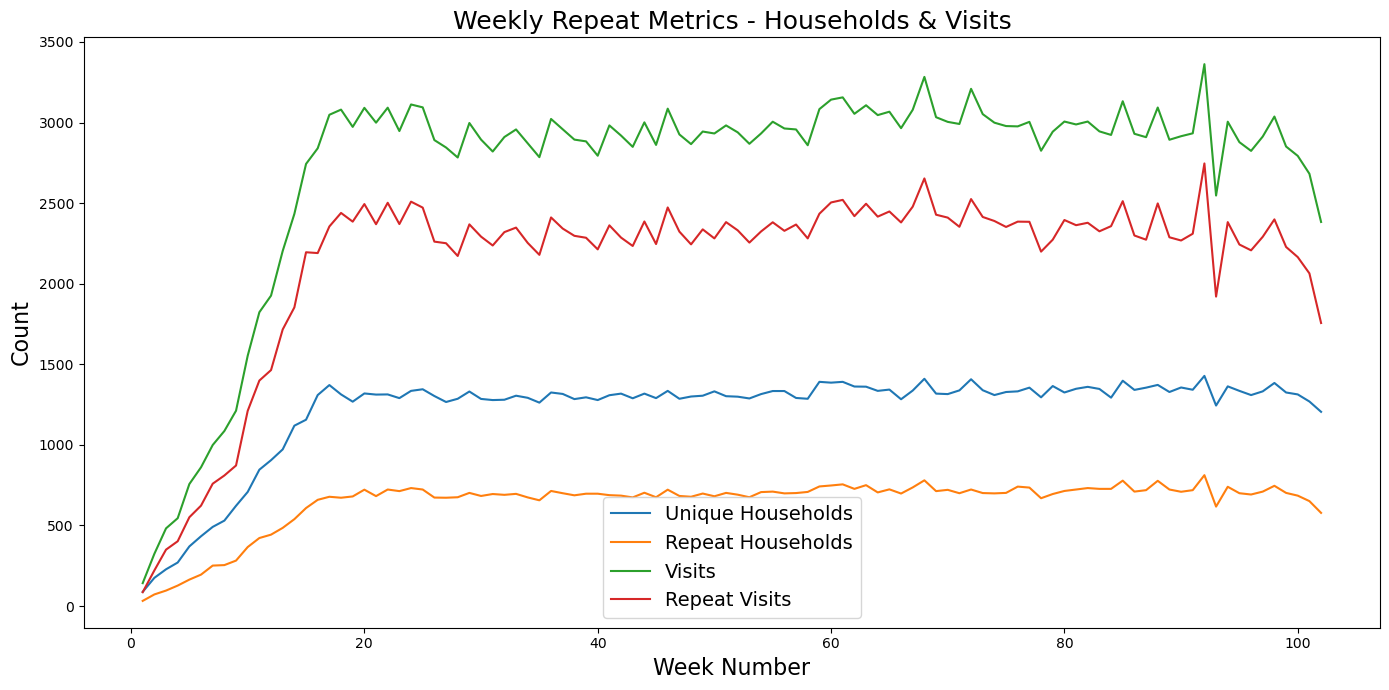

In [51]:


# Load weekly transaction metrics table
weekly_df = pd.read_csv("./weekly_transaction_metrics.csv")

# Plot weekly transaction KPIs
plt.figure(figsize=(14, 8))
# Weekly & Repeat Metrics
weekly_df = pd.read_csv("./weekly_transaction_metrics.csv")

plt.figure(figsize=(14, 7))
plt.plot(weekly_df["WEEK_NO"], weekly_df["unique_households"], label="Unique Households")
plt.plot(weekly_df["WEEK_NO"], weekly_df["repeat_households"], label="Repeat Households")
plt.plot(weekly_df["WEEK_NO"], weekly_df["unique_transactions"], label="Visits")
plt.plot(weekly_df["WEEK_NO"], weekly_df["repeat_transactions"], label="Repeat Visits")
plt.xlabel("Week Number", fontsize=16)
plt.ylabel("Count", fontsize=16)
plt.title("Weekly Repeat Metrics - Households & Visits", fontsize=18)
plt.legend(fontsize=14)
plt.grid(False)
plt.tight_layout()
plt.show()


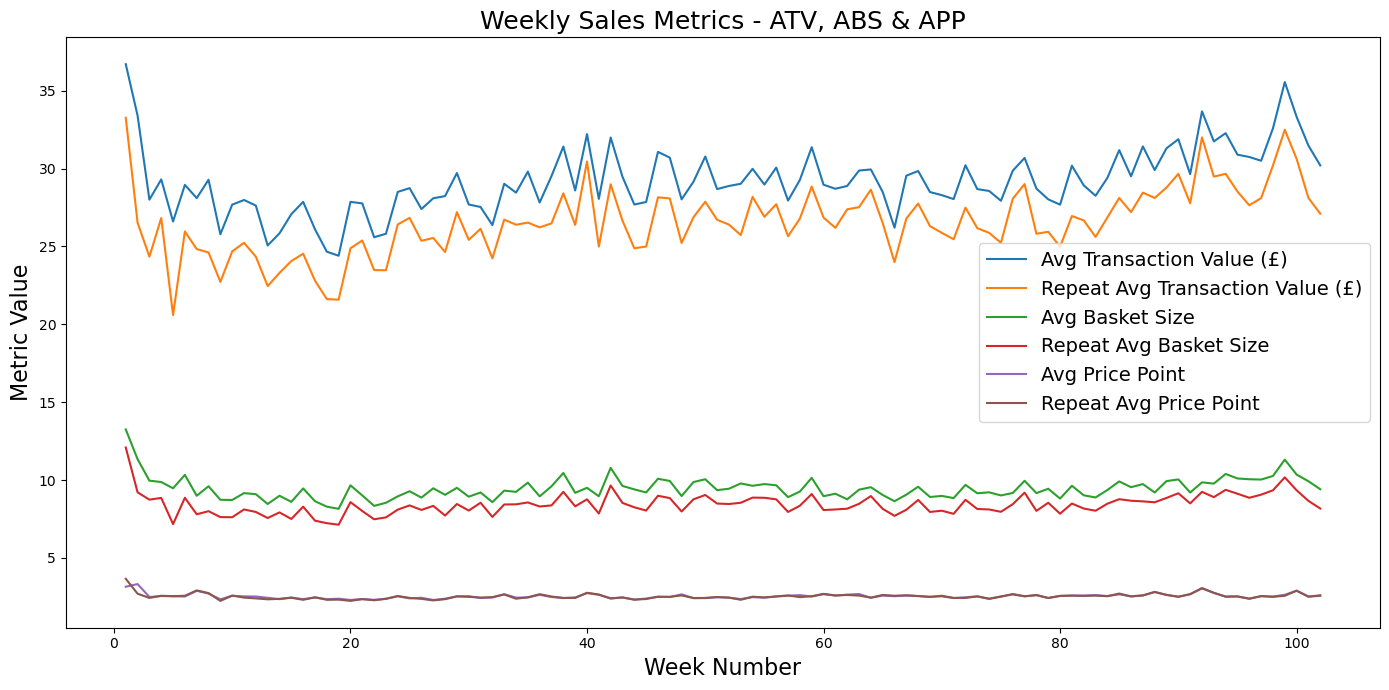

In [52]:
#  Weekly Sales Metrics
plt.figure(figsize=(14, 7))
plt.plot(weekly_df["WEEK_NO"], weekly_df["avg_transaction_value"], label="Avg Transaction Value (£)")
plt.plot(weekly_df["WEEK_NO"], weekly_df["repeat_avg_transaction_value"], label="Repeat Avg Transaction Value (£)")
plt.plot(weekly_df["WEEK_NO"], weekly_df["avg_basket_size"], label="Avg Basket Size")
plt.plot(weekly_df["WEEK_NO"], weekly_df["repeat_avg_basket_size"], label="Repeat Avg Basket Size")
plt.plot(weekly_df["WEEK_NO"], weekly_df["avg_price_point"], label="Avg Price Point")
plt.plot(weekly_df["WEEK_NO"], weekly_df["repeat_avg_price_point"], label="Repeat Avg Price Point")
plt.xlabel("Week Number", fontsize=16)
plt.ylabel("Metric Value", fontsize=16)
plt.title("Weekly Sales Metrics - ATV, ABS & APP", fontsize=18)
plt.legend(fontsize=14)
plt.grid(False)
plt.tight_layout()
plt.show()


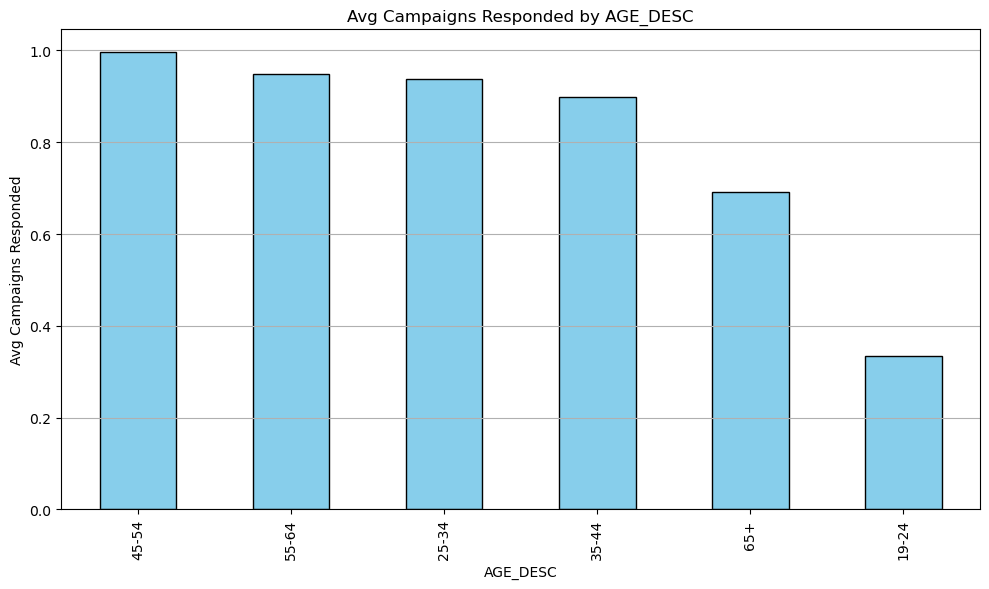

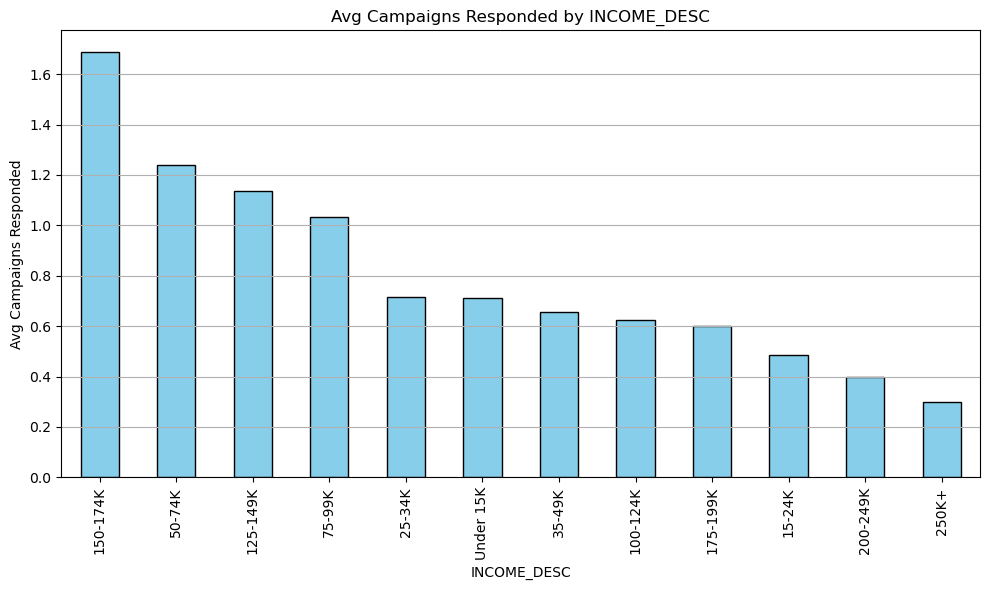

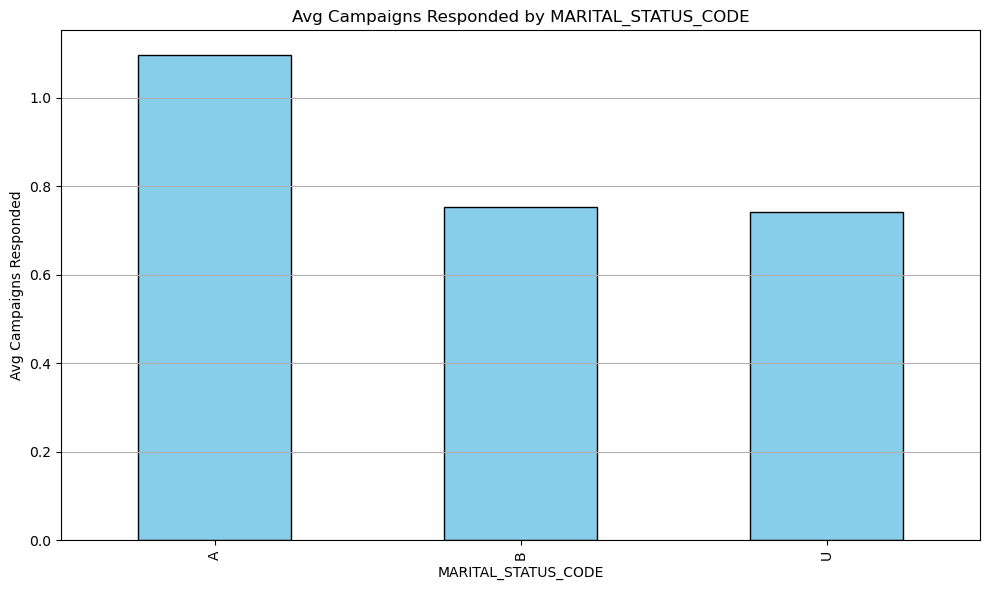

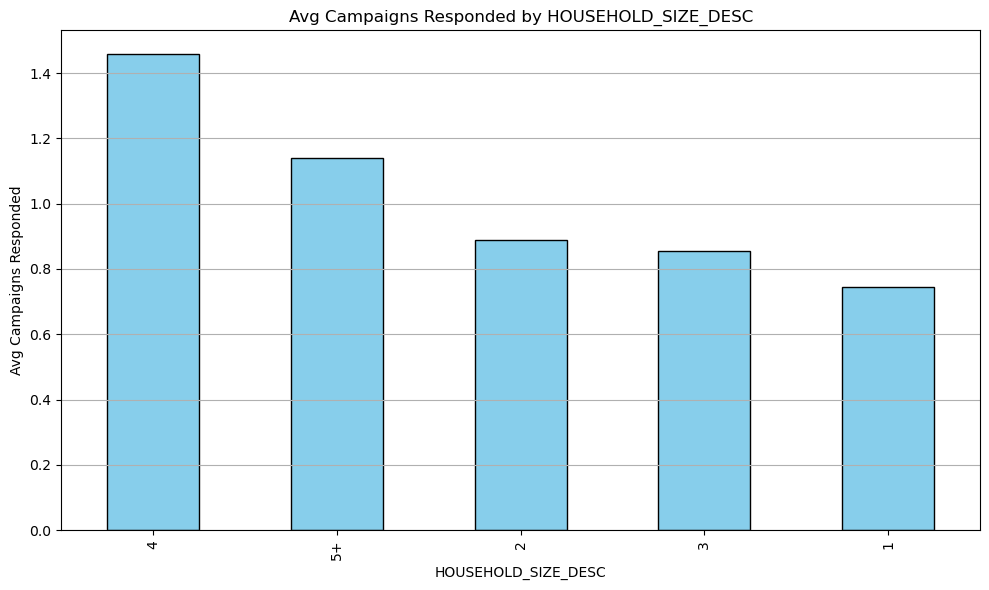

In [53]:
# Campaign Responsiveness by Segment
campaign_df = df_subset.copy()

segment_cols = ["AGE_DESC", "INCOME_DESC", "MARITAL_STATUS_CODE", "HOUSEHOLD_SIZE_DESC"]
for col in segment_cols:
    plt.figure(figsize=(10, 6))
    campaign_group = campaign_df.groupby(col)["campaigns_responded"].mean().sort_values(ascending=False)
    campaign_group.plot(kind="bar", color="skyblue", edgecolor="black")
    plt.title(f"Avg Campaigns Responded by {col}")
    plt.ylabel("Avg Campaigns Responded")
    plt.xlabel(col)
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


C:\Users\sachi\AppData\Local\Temp\ipykernel_42216\681912327.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('coolwarm', len(top_depts))


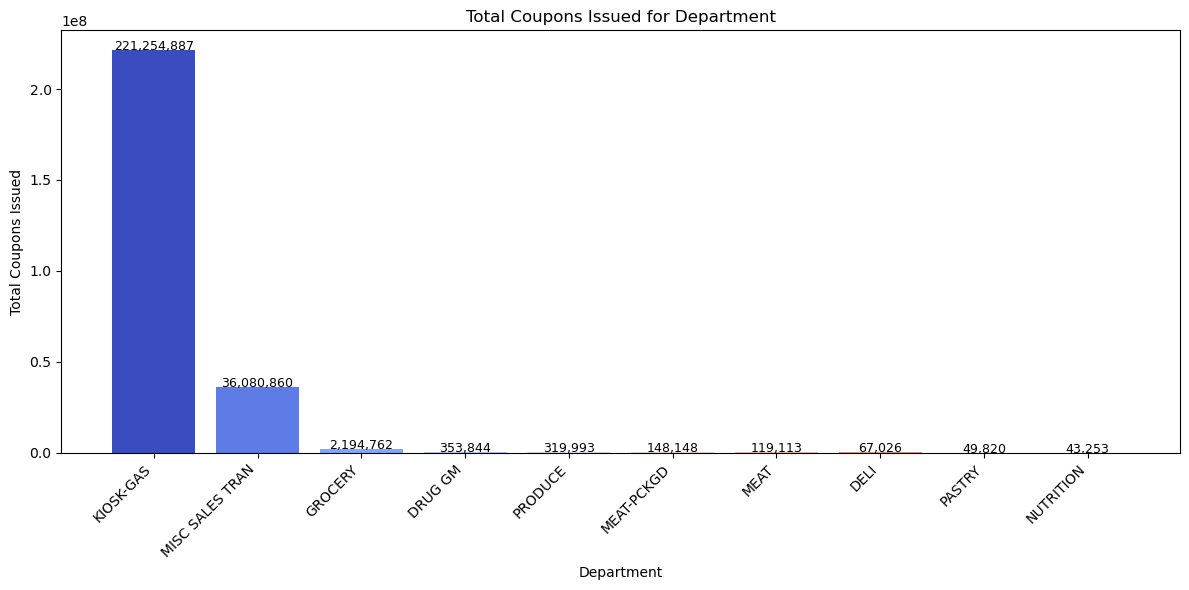

In [54]:

top_depts = df_coupon_comparison.sort_values(by="total_qty", ascending=False).head(10)

colors = plt.cm.get_cmap('coolwarm', len(top_depts))

plt.figure(figsize=(12, 6))
bars = plt.bar(top_depts["DEPARTMENT"], top_depts["total_qty"], color=colors(range(len(top_depts))))

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f"{int(bar.get_height()):,}", ha='center', fontsize=9)

plt.title("Total Coupons Issued for Department")
plt.xlabel("Department")
plt.ylabel("Total Coupons Issued")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


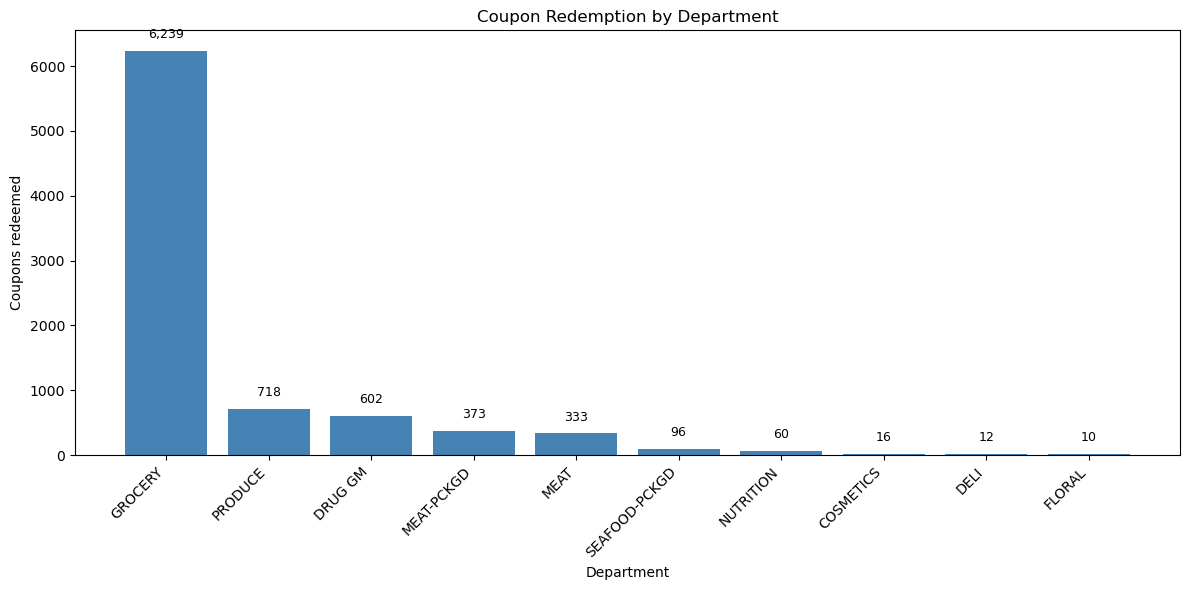

In [55]:
# Sort top 10 by coupon_qty
top_coupon = df_coupon_comparison.sort_values(by="coupon_qty", ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(top_coupon["DEPARTMENT"], top_coupon["coupon_qty"], color="steelblue")

# Labels
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f"{int(bar.get_height()):,}", ha='center', fontsize=9)

plt.title("Coupon Redemption by Department")
plt.xlabel("Department")
plt.ylabel("Coupons redeemed")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### We notice that even though the highest number of coupons are issued for Kiosk-Gas and Miscellaneous the highest redemptions are done for Groceries - This is probably driven by the essential nature of groceries and their recurrent purchases.

#### Plotting Daily Sales Trend

This code generates a line plot to visualize the daily sales trend. It groups the data by `DAY` and calculates the sum of `SALES_VALUE` for each day.  
A line plot is created using Seaborn to show how sales values change over time, with a marker on each data point.  

#### The below plot shows the weekly variation in footfall. The high variance is due to high footfall over the weekend which is a recurrent trend for all weeks when the store is open for business.

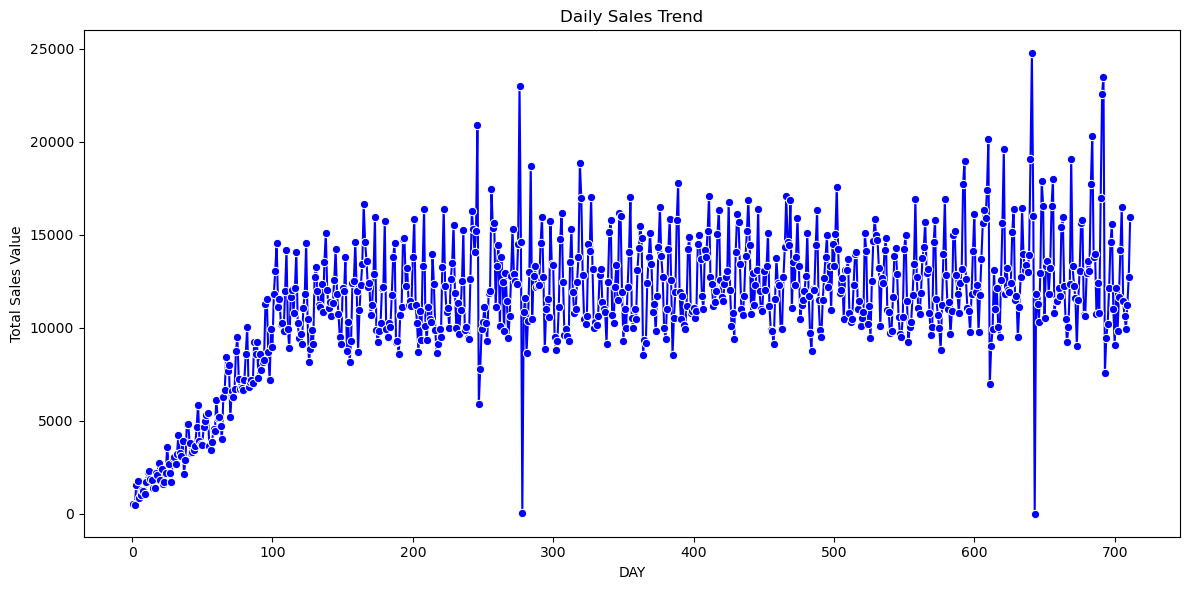

In [58]:
daily_sales = transactions_df.groupby('DAY')['SALES_VALUE'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x='DAY', y='SALES_VALUE', data=daily_sales, marker='o', color='blue')
plt.xlabel('DAY')
plt.ylabel('Total Sales Value')
plt.title('Daily Sales Trend')
plt.tight_layout()
plt.show()

#### Categorizing Transactions by Time of Day

This function categorizes transaction times into four periods: Morning, Afternoon, Evening, and Night based on the hour.  
The transactions are then grouped by these categories and visualized using a count plot to show the distribution of transactions across different times of the day.  


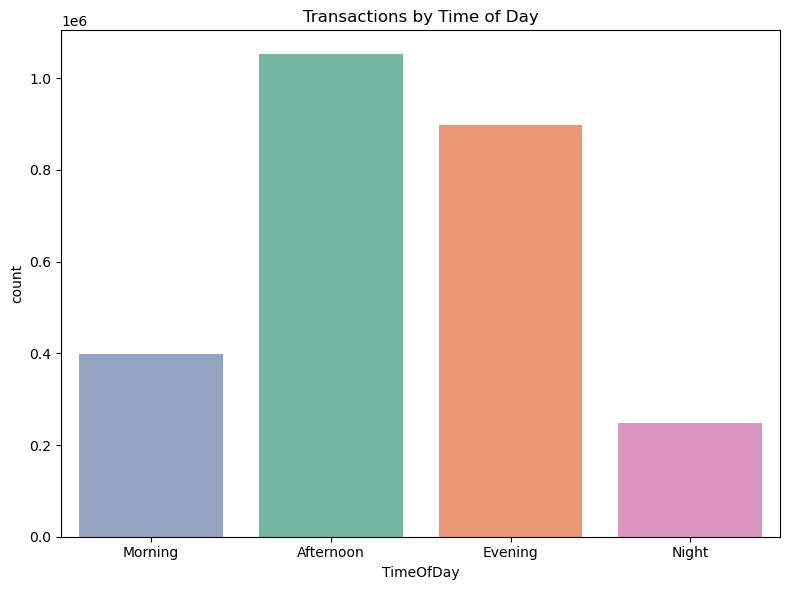

In [60]:
def get_time_of_day(time_val):
    hour = int(str(time_val).zfill(4)[:2])
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

transactions_df['TimeOfDay'] = transactions_df['TRANS_TIME'].apply(get_time_of_day)




plt.figure(figsize=(8, 6))
sns.countplot(
    x='TimeOfDay',
    hue='TimeOfDay',
    data=transactions_df,
    order=['Morning', 'Afternoon', 'Evening', 'Night'],
    palette='Set2',
    legend=False )
plt.title('Transactions by Time of Day')
plt.tight_layout()
plt.show()


#### RFM Segmentation: Recency, Frequency, and Monetary Analysis

This code calculates the RFM (Recency, Frequency, and Monetary) metrics for customer segmentation.  
The `NetSpend` is calculated as the sum of the sales value and all discounts applied to each transaction.  
After calculating RFM metrics for each customer, the values are normalized for easier visualization.  
The scatter plot visualizes customer segmentation by plotting frequency against monetary values, with bubble sizes and colors representing recency.  


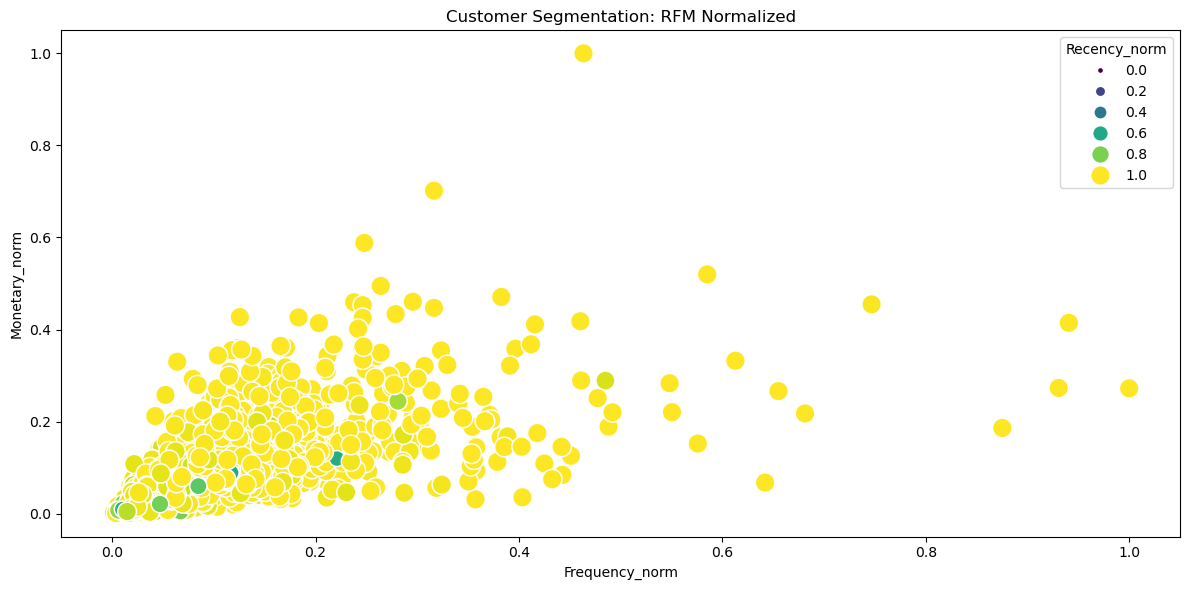

In [62]:
# RFM
# net sepnd = SALES_VALUE + all discounts
transactions_df['NetSpend'] = transactions_df['SALES_VALUE'] + transactions_df['RETAIL_DISC'] + transactions_df['COUPON_DISC'] + transactions_df['COUPON_MATCH_DISC']
customer_rfm = transactions_df.groupby('household_key').agg(
    Recency=('DAY', 'max'),
    Frequency=('BASKET_ID', pd.Series.nunique),
    Monetary=('NetSpend', 'sum')
).reset_index()

# normalize for plotting
customer_rfm[['Recency_norm', 'Frequency_norm', 'Monetary_norm']] = customer_rfm[['Recency', 'Frequency', 'Monetary']].apply(lambda x: (x - x.min()) / (x.max() - x.min()))

plt.figure(figsize=(12, 6))
sns.scatterplot(data=customer_rfm, x='Frequency_norm', y='Monetary_norm', size='Recency_norm', hue='Recency_norm', palette='viridis', sizes=(20, 200))
plt.title('Customer Segmentation: RFM Normalized')
plt.tight_layout()
plt.show()

#### Calculating RFM Segmentation and Visualizing the Distribution of RFM Scores

This code calculates Recency, Frequency, and Monetary (RFM) metrics for customer segmentation.  
The `Date` column is created by adding the number of days to a starting date. The `Time` column is created by converting transaction times into timedeltas, and a `Datetime` column is formed by combining the `Date` and `Time`.  
Recency is then calculated by subtracting the most recent transaction from the current date, and Frequency and Monetary values are calculated for each customer.  
The RFM scores are derived by categorizing each metric into quartiles, and then customers are segmented based on their RFM score.  
Finally, a bar plot is created to visualize the distribution of customers across different RFM scores.  


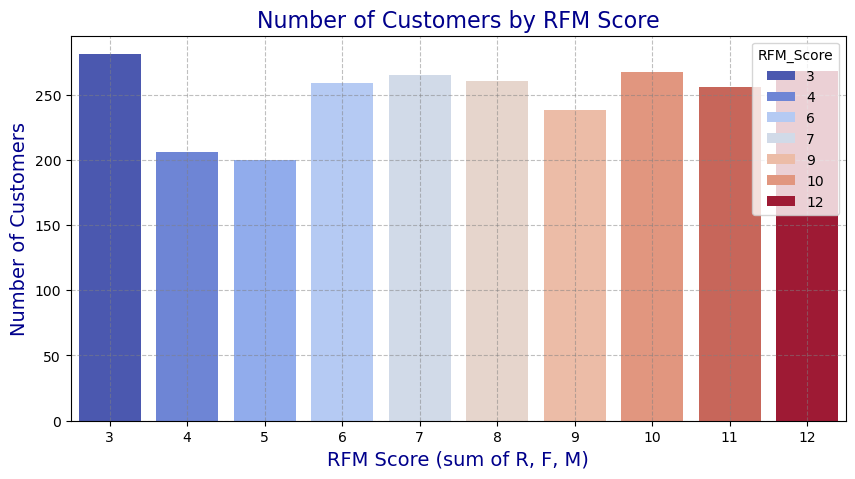

In [64]:

start_date = pd.to_datetime('2020-01-01')

transactions_df['Date'] = start_date + pd.to_timedelta(transactions_df['DAY'], unit='D')
transactions_df['Time'] = pd.to_timedelta(transactions_df['TRANS_TIME'], unit='m')
transactions_df['Datetime'] = transactions_df['Date'] + transactions_df['Time']

# Calculate the snapshot
snapshot = transactions_df['Datetime'].max() + pd.Timedelta(days=1)

# Calculate RFM metrics
rfm = transactions_df.groupby('household_key').agg(
    recency=('Datetime', lambda x: (snapshot - x.max()).days),
    frequency=('BASKET_ID', 'nunique'),
    monetary=('SALES_VALUE', 'sum')
).reset_index()

def safe_qcut(series, q, labels, reverse=False):
    unique_vals = series.nunique()
    bins = min(q, unique_vals)
    try:
        scored = pd.qcut(series, q=bins, labels=labels[:bins], duplicates='drop')
        return scored.astype(int) if not reverse else scored.astype(int).map(lambda x: labels[bins - 1 - x])
    except ValueError:
        return pd.Series([labels[bins//2]] * len(series))

rfm['R_Score'] = safe_qcut(rfm['recency'], 4, labels=[4, 3, 2, 1], reverse=False)
rfm['F_Score'] = safe_qcut(rfm['frequency'], 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = safe_qcut(rfm['monetary'], 4, labels=[1, 2, 3, 4])

rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

top_customers = rfm.sort_values(by='RFM_Score', ascending=False).head()

rfm['RFM_Score'] = rfm['RFM_Score'].astype(int)

rfm_counts = rfm['RFM_Score'].value_counts().sort_index().reset_index()
rfm_counts.columns = ['RFM_Score', 'Count']

plt.figure(figsize=(10, 5))
sns.barplot(x='RFM_Score', y='Count', data=rfm_counts, hue='RFM_Score', palette='coolwarm', dodge=False)

plt.title('Number of Customers by RFM Score', fontsize=16, color='darkblue')
plt.xlabel('RFM Score (sum of R, F, M)', fontsize=14, color='darkblue')
plt.ylabel('Number of Customers', fontsize=14, color='darkblue')

plt.grid(True, linestyle='--', color='gray', alpha=0.5)

plt.show()


#### RFM Segmentation and Visualization
This code performs Recency, Frequency, and Monetary (RFM) analysis based on transaction data.
We calculate the time of the last transaction for each customer (recency), the number of distinct baskets (frequency),
and the total spend (monetary). We then segment customers based on their RFM scores and visualize the distribution.


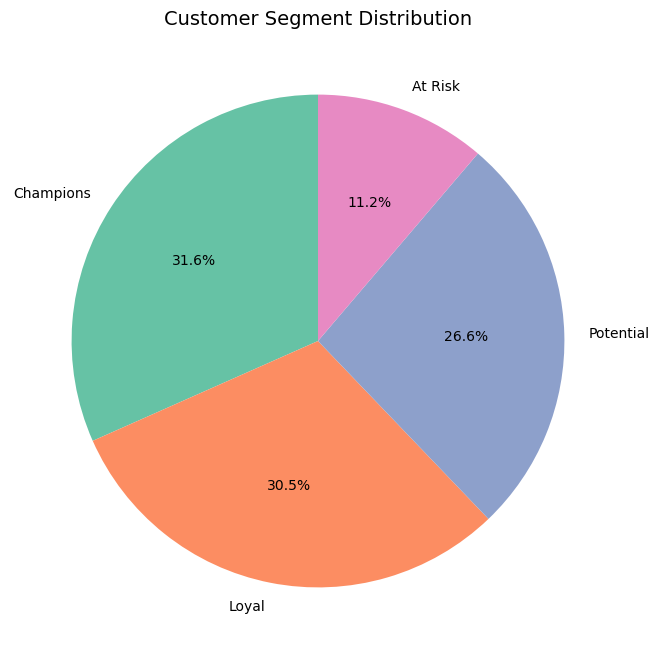

In [66]:
def segment_customer(row):
    if row['RFM_Score'] >= 10:
        return 'Champions'
    elif row['RFM_Score'] >= 7:
        return 'Loyal'
    elif row['RFM_Score'] >= 4:
        return 'Potential'
    else:
        return 'At Risk'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set2', n_colors=4), startangle=90)

plt.title('Customer Segment Distribution', fontsize=14)

plt.show()



# 3. Feature importance
#### What are the top features causing variability in purchase behaviour?
##### We model the data with total sales as the dependent variable - Our objective is to get mutually exclusive segments which can be leveraged for customer targeting strategies

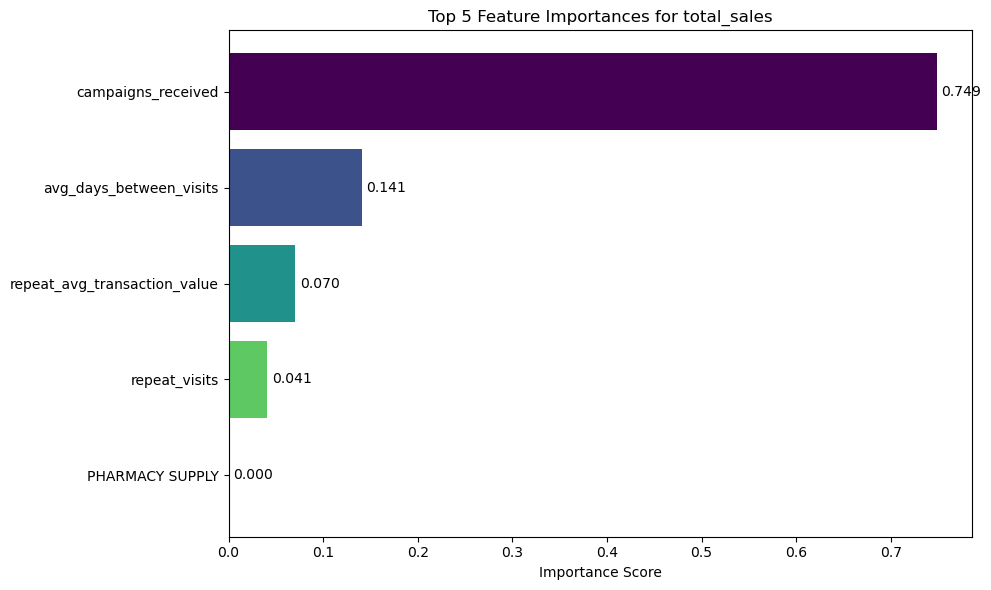

Exported top 5 feature importance plot to ./feature_importance_top5.png


In [70]:
# Feature Importance using df_merged
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder

# Prepare data
df_model = df_merged.copy().dropna(subset=["total_sales"]).copy()

# Encode categorical variables
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

# Define features and target
X_merged = df_model.drop(columns=["household_key", "total_sales"])
y_merged = df_model["total_sales"]

# Fit Decision Tree
tree_merged = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_merged.fit(X_merged, y_merged)

# Feature Importance Plot (Top 5)
importances = tree_merged.feature_importances_
feature_names = X_merged.columns

imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(5)

# Plot
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(imp_df)))

bars = plt.barh(imp_df["Feature"], imp_df["Importance"], color=colors)
plt.xlabel("Importance Score")
plt.title("Top 5 Feature Importances for total_sales")
plt.gca().invert_yaxis()

# Annotate bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, f"{width:.3f}", va="center")

plt.tight_layout()
top5_path = "./feature_importance_top5.png"
plt.savefig(top5_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Exported top 5 feature importance plot to {top5_path}")


#### Study multi-collinearity of independent parameters

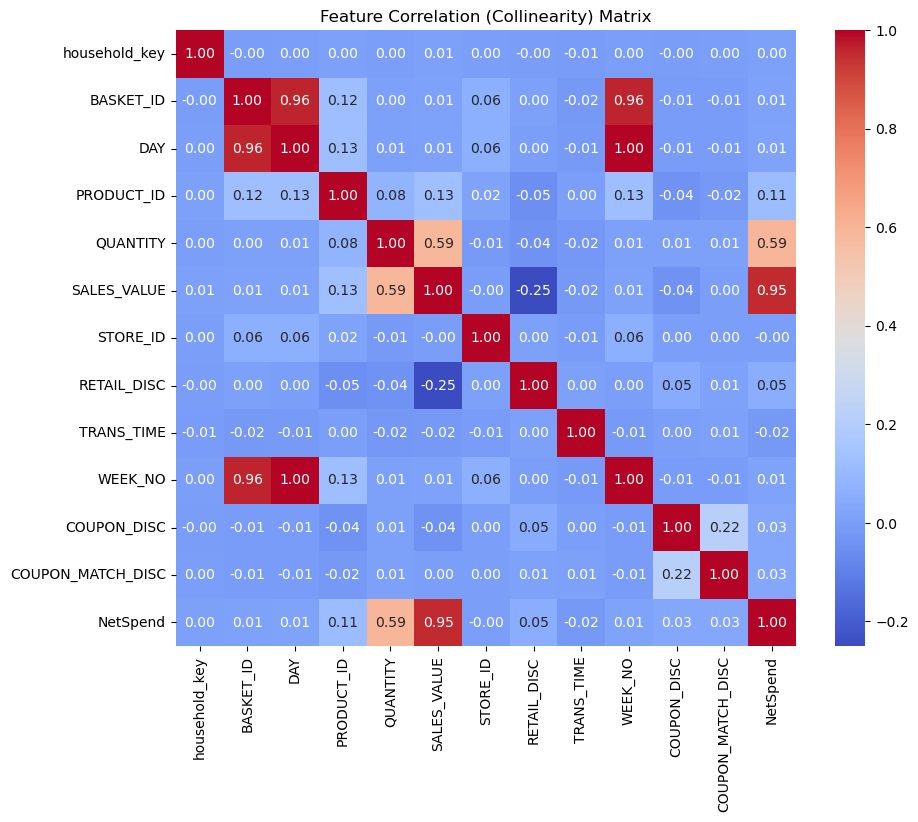

In [72]:
correlation_matrix = transactions_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation (Collinearity) Matrix')
plt.show()

# 4. ML: Creating Segments
#### Final run of decision trees to create binary tree with important features
##### After running multiple iterations, we limit our tree to a depth=3

In [74]:
!pip install --upgrade scikit-learn


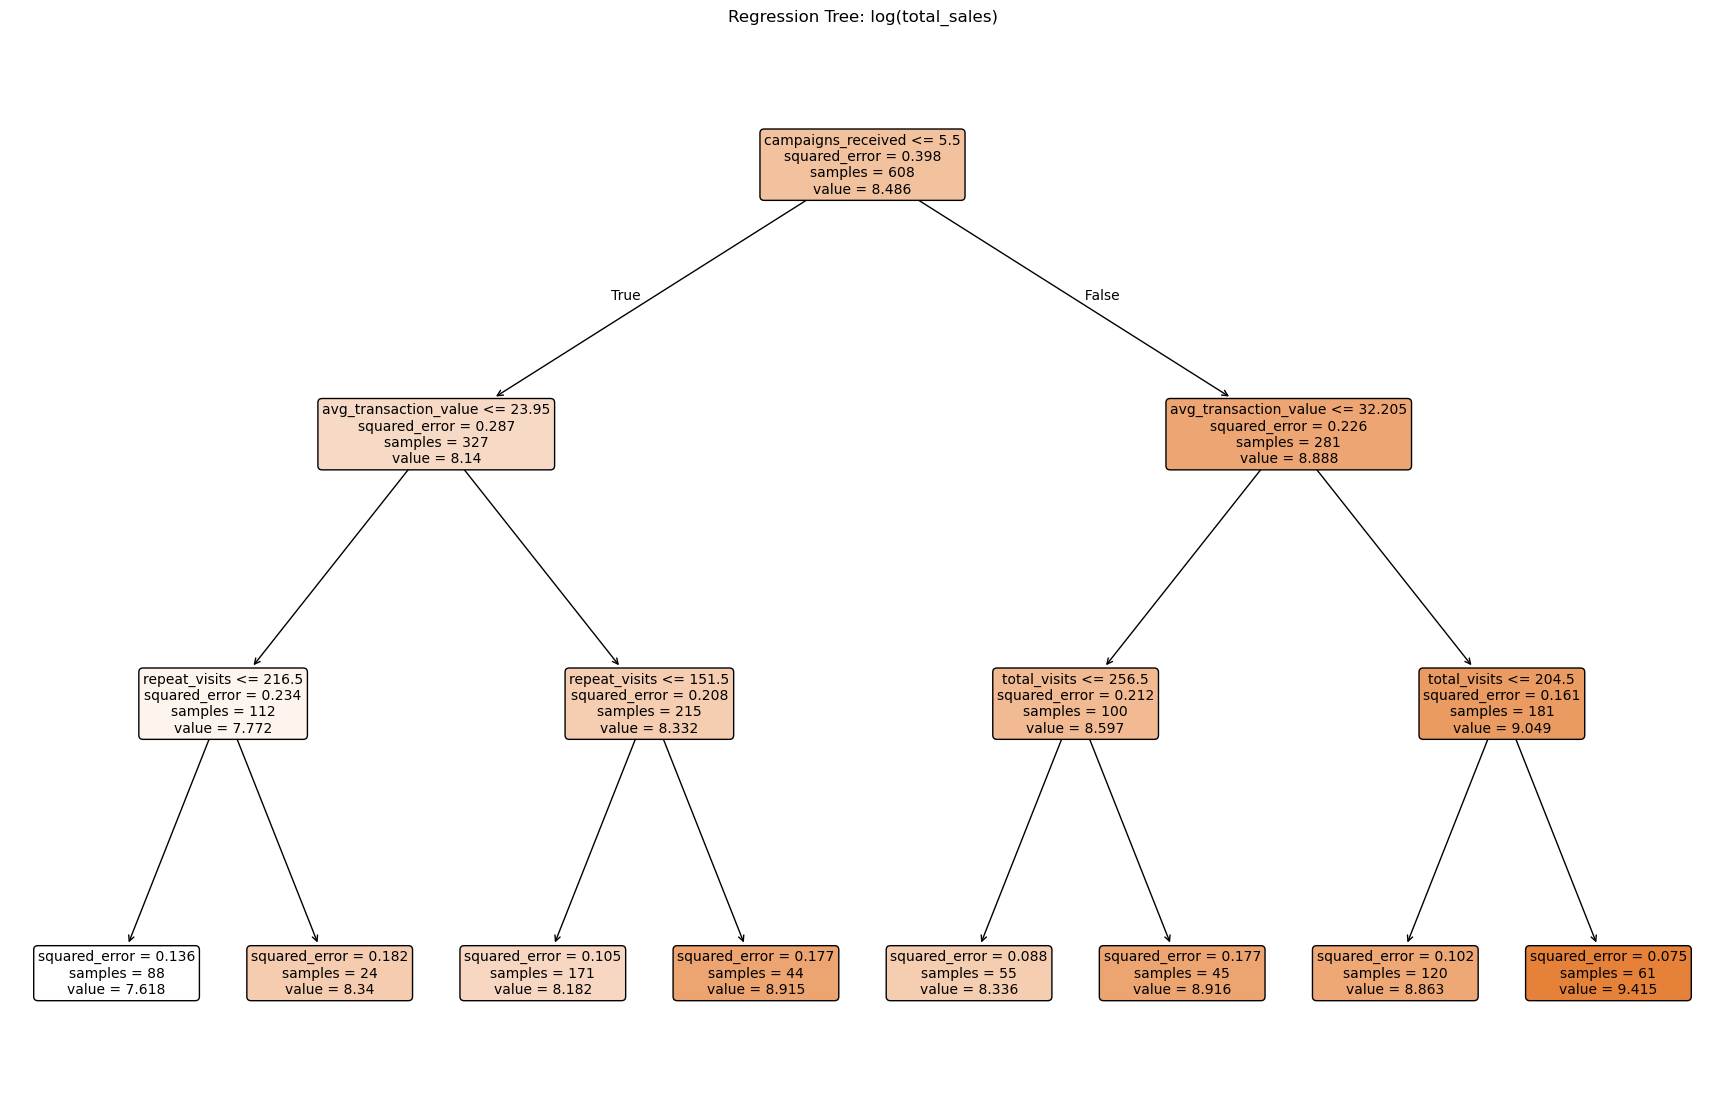

|--- campaigns_received <= 5.50
|   |--- avg_transaction_value <= 23.95
|   |   |--- repeat_visits <= 216.50
|   |   |   |--- value: [7.62]
|   |   |--- repeat_visits >  216.50
|   |   |   |--- value: [8.34]
|   |--- avg_transaction_value >  23.95
|   |   |--- repeat_visits <= 151.50
|   |   |   |--- value: [8.18]
|   |   |--- repeat_visits >  151.50
|   |   |   |--- value: [8.92]
|--- campaigns_received >  5.50
|   |--- avg_transaction_value <= 32.20
|   |   |--- total_visits <= 256.50
|   |   |   |--- value: [8.34]
|   |   |--- total_visits >  256.50
|   |   |   |--- value: [8.92]
|   |--- avg_transaction_value >  32.20
|   |   |--- total_visits <= 204.50
|   |   |   |--- value: [8.86]
|   |   |--- total_visits >  204.50
|   |   |   |--- value: [9.41]

RMSE (log-scale): 0.3762
R² Score        : 0.6017


In [75]:


# Load and prepare data
df = pd.read_csv("./household_subset_for_modeling.csv")

# Drop rows with missing values
df_cleaned = df.dropna().copy()

# Encode all categorical (object-type) columns
for col in df_cleaned.select_dtypes(include="object").columns:
    df_cleaned[col] = LabelEncoder().fit_transform(df_cleaned[col].astype(str))

# Log-transform the target variable
df_cleaned["log_total_sales"] = np.log1p(df_cleaned["total_sales"])


X_log = df_cleaned.drop(columns=["household_key", "total_sales", "log_total_sales"])
y_log = df_cleaned["log_total_sales"]

# Train/test split
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

# Train Decisicon Tree
log_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
log_tree.fit(X_train_log, y_train_log)

# Plot Decisicon Tree
plt.figure(figsize=(22, 14))
plot_tree(
    log_tree,
    feature_names=X_log.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Regression Tree: log(total_sales)")
plt.show()

# Print tree rules
rules = export_text(log_tree, feature_names=list(X_log.columns))
print(rules)

# Evaluate model
y_pred_log = log_tree.predict(X_test_log)
rmse = sqrt(mean_squared_error(y_test_log, y_pred_log))
r2 = r2_score(y_test_log, y_pred_log)

print(f"RMSE (log-scale): {rmse:.4f}")
print(f"R² Score        : {r2:.4f}")


# 5. Evaluation of created segments

### 5.1 Plot predictions vs actuals


📈 Model Performance on Test Set
RMSE (in £): £0.38
R² Score     : 0.5559


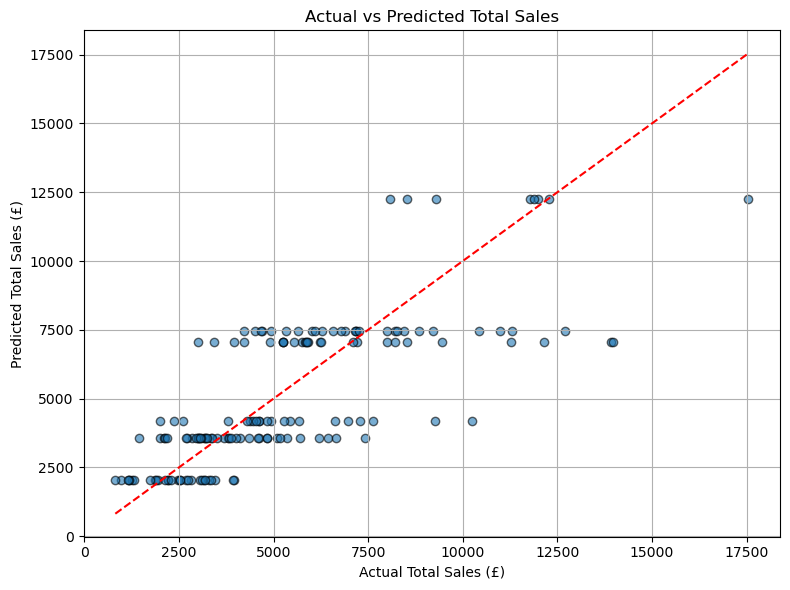

📂 Exported prediction comparison plot to ./predicted_vs_actual_sales.png


In [78]:
# Evaluate model on test set
y_pred_log = log_tree.predict(X_test_log)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test_log)

rmse = sqrt(mean_squared_error(y_test_log, y_pred_log))
r2 = r2_score(y_actual, y_pred)

print(f"\n\U0001F4C8 Model Performance on Test Set")
print(f"RMSE (in \u00a3): \u00a3{rmse:,.2f}")
print(f"R² Score     : {r2:.4f}")

# Plot predictions vs actuals
plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_pred, alpha=0.6, edgecolor='k')
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--')
plt.xlabel("Actual Total Sales (£)")
plt.ylabel("Predicted Total Sales (£)")
plt.title("Actual vs Predicted Total Sales")
plt.grid(True)
plt.tight_layout()

# Export to summary chart
summary_chart_path = "./predicted_vs_actual_sales.png"
plt.savefig(summary_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\U0001F4C2 Exported prediction comparison plot to {summary_chart_path}")


### 5.2 Residual Plot Distribution

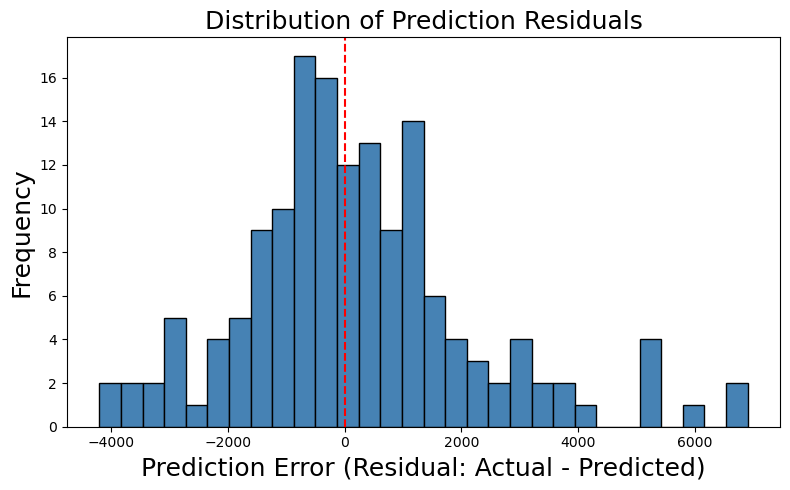

Exported residual distribution plot to ./residual_distribution.png


In [80]:
# Plot: Residual Distribution
residuals = y_actual - y_pred

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, edgecolor='black', color='steelblue')
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Prediction Residuals", fontsize=18)
plt.xlabel("Prediction Error (Residual: Actual - Predicted)", fontsize=18)
plt.ylabel("Frequency", fontsize=18)
plt.tight_layout()

# Save and show
residual_path = "./residual_distribution.png"
plt.savefig(residual_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Exported residual distribution plot to {residual_path}")


### **5.3 Key insights from the Prediction error:**



##### **Distribution shape :**

##### The residuals are roughly normally distributed, centered near zero.

##### This is a good sign — it suggests the model doesn’t systematically over or under-predict.

#### **Bias check :**

##### The red dashed line at 0 marks perfect prediction.

##### Since the peak is slightly left of the red line, there may be a slight under-prediction bias for many households.

#### **Spread and variability:**

##### The tails are longer on the right, indicating larger over-predictions are more common than large under-predictions.

#### **Outliers:**

##### A few households have very large errors (±4000+), which could merit further investigation or exclusion if they’re anomalies.

### 5.4 Visually Assessment: Heteroscedasticity or Pattern bias

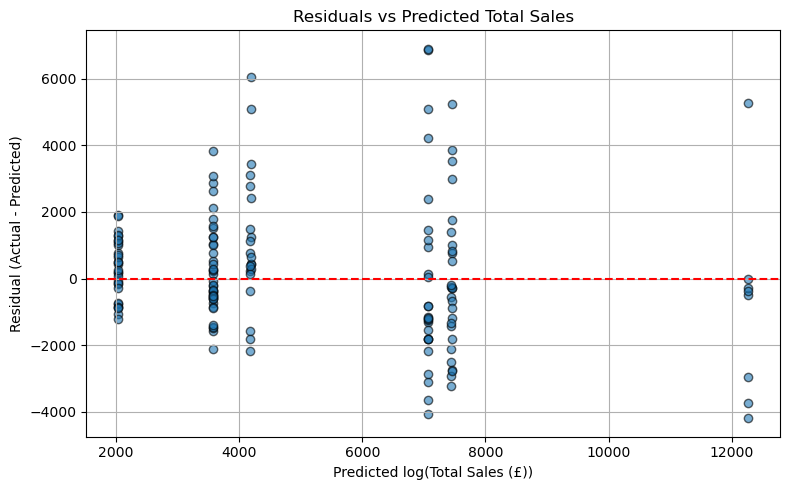

📂 Exported residuals vs predicted plot to ./residuals_vs_predicted.png


In [84]:
# Plot: Residuals vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6, edgecolor='k')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted log(Total Sales (£))")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted Total Sales")
plt.grid(True)
plt.tight_layout()

residual_scatter_path = "./residuals_vs_predicted.png"
plt.savefig(residual_scatter_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\U0001F4C2 Exported residuals vs predicted plot to {residual_scatter_path}")


#### **Issue: What it means**
#### Heteroscedasticity: Model error is not evenly distributed — likely underfitting higher spenders.
#### Bias: Tree may be missing splits relevant for larger spend segments.
#### Tree depth: Tree restricted to max_depth=3 may be too shallow to capture full variance.

### **"We choose to keep the depth to 3 as we do not want too many segments, although with high variance, they will not have very different targeting strategies"**

# 6. Merge Customer segments based on B2C Marketing heuristics

In [87]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load and clean
df = pd.read_csv("./household_subset_for_modeling.csv")
df_cleaned = df.dropna().copy()

# Encode ALL object-type columns safely
for col in df_cleaned.select_dtypes(include="object").columns:
    df_cleaned[col] = LabelEncoder().fit_transform(df_cleaned[col].astype(str))

# Log-transform total_sales
df_cleaned["log_total_sales"] = np.log1p(df_cleaned["total_sales"])

# Define features and target
X = df_cleaned.drop(columns=["household_key", "total_sales", "log_total_sales"])
y = df_cleaned["log_total_sales"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
df_cleaned = df_cleaned.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)

# Train Decision Tree
tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

# Segment assignment
leaf_nodes = tree.apply(X_train)
segment_map = {node: i for i, node in enumerate(np.unique(leaf_nodes))}
df_cleaned.loc[X_train.index, "segment"] = pd.Series(leaf_nodes).map(segment_map)

# Merge segment nodes
merge_map = {3: 34, 4: 34, 10: 1011, 11: 1011}
df_cleaned["segment"] = df_cleaned["segment"].replace(merge_map)

# Profile segments
profile = df_cleaned.groupby("segment").agg(
    n_households=("household_key", "count"),
    total_sales=("total_sales", "sum"),
    avg_sales=("total_sales", "mean"),
    ATV=("avg_transaction_value", "mean"),
    ABS=("avg_basket_size", "mean"),
    APP=("avg_price_point", "mean"),
    avg_visits=("total_visits", "mean"),
    avg_repeat_visits=("repeat_visits", "mean"),
    visit_latency=("avg_days_between_visits", "mean"),
    repeat_rate=("repeat_visits", lambda x: 100 * np.mean(x / df_cleaned.loc[x.index, "total_visits"])),
    coupon_use_rate=("coupons_redeemed", lambda x: 100 * np.mean(x > 0))
).round(2).reset_index()

# Export segment profile
profile_path = "./merged_segment_profiles.csv"
profile.to_csv(profile_path, index=False)
print(f"Exported segment profiles to: {profile_path}")


Exported segment profiles to: ./merged_segment_profiles.csv


In [88]:



df = pd.read_csv("./household_subset_for_modeling.csv")
df_cleaned = df.dropna().copy()

# Encode ALL object-type columns
for col in df_cleaned.select_dtypes(include="object").columns:
    df_cleaned[col] = LabelEncoder().fit_transform(df_cleaned[col].astype(str))

# Log-transform sales
df_cleaned["log_total_sales"] = np.log1p(df_cleaned["total_sales"])

# Split and train decision tree
X = df_cleaned.drop(columns=["household_key", "total_sales", "log_total_sales"])
y = df_cleaned["log_total_sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
df_cleaned = df_cleaned.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)

tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
leaf_nodes = tree.apply(X_train)
segment_map = {node: i for i, node in enumerate(np.unique(leaf_nodes))}
df_cleaned.loc[X_train.index, "segment"] = pd.Series(leaf_nodes).map(segment_map)

# Optional mErge of some leaf nodes
merge_map = {3: 34, 4: 34, 10: 1011, 11: 1011}
df_cleaned["segment"] = df_cleaned["segment"].replace(merge_map)

#  Segment Profile
segment_profile = df_cleaned.groupby("segment").agg(
    n_households=("household_key", "count"),
    total_sales=("total_sales", "sum"),
    avg_sales=("total_sales", "mean"),
    ATV=("avg_transaction_value", "mean"),
    ABS=("avg_basket_size", "mean"),
    APP=("avg_price_point", "mean"),
    avg_visits=("total_visits", "mean"),
    avg_repeat_visits=("repeat_visits", "mean"),
    visit_latency=("avg_days_between_visits", "mean"),
    repeat_rate=("repeat_visits", lambda x: 100 * np.mean(x / df_cleaned.loc[x.index, "total_visits"])),
    coupon_use_rate=("coupons_redeemed", lambda x: 100 * np.mean(x > 0))
).round(2).reset_index()

# Export and display
segment_profile.to_csv("./merged_segment_profiles.csv", index=False)
print("Exported merged_segment_profiles.csv")
display(segment_profile)
# Department Composition
# Load household-level dept summary
df_summary = pd.read_csv("./household_behavior_summary_with_dept.csv")
df_segmented = df_cleaned[["household_key", "segment"]].merge(df_summary, on="household_key", how="left")

# Fiter valid department columns
correct_depts = [
    "AUTOMOTIVE", "CHARITABLE CONT", "CHEF SHOPPE", "CNTRL/STORE SUP", "COSMETICS",
    "COUP/STR & MFG", "DAIRY DELI", "DELI", "DELI/SNACK BAR", "DRUG GM", "ELECT &PLUMBING",
    "FLORAL", "FROZEN GROCERY", "GARDEN CENTER", "GM MERCH EXP", "GRO BAKERY", "GROCERY",
    "HBC", "HOUSEWARES", "KIOSK-GAS", "MEAT", "MEAT-PCKGD", "MEAT-WHSE", "MISC SALES TRAN",
    "MISC. TRANS.", "NUTRITION", "PASTRY", "PHARMACY SUPPLY", "PHOTO", "PORK", "POSTAL CENTER",
    "PROD-WHS SALES", "PRODUCE", "RESTAURANT", "RX", "SALAD BAR", "SEAFOOD", "SEAFOOD-PCKGD",
    "SPIRITS", "TOYS", "TRAVEL & LEISUR", "VIDEO", "VIDEO RENTAL"
]
dept_columns = [col for col in correct_depts if col in df_segmented.columns and pd.api.types.is_numeric_dtype(df_segmented[col])]

# % contribution per department
dept_share = df_segmented.groupby("segment")[dept_columns].mean().round(2)

# £ contribution per department
for dept in dept_columns:
    df_segmented[f"{dept}_£"] = df_segmented[dept] * df_segmented["total_sales"] / 100
monetary_share = df_segmented.groupby("segment")[[f"{dept}_£" for dept in dept_columns]].mean().round(2)

# Combine % and £ views
segment_composition = pd.concat([dept_share, monetary_share], axis=1)
segment_composition.to_csv("./segment_department_composition.csv", index=True)
print("Exported segment_department_composition.csv")

# Show results in notebook
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
display(segment_composition.reset_index())


Exported merged_segment_profiles.csv


,segment,n_households,total_sales,avg_sales,ATV,ABS,APP,avg_visits,avg_repeat_visits,visit_latency,repeat_rate,coupon_use_rate
0,0.0,79,398705.51,5046.91,32.91,10.70,2.54,175.72,175.72,5.64,100.0,34.18
1,1.0,23,153657.35,6680.75,43.33,13.62,2.44,195.70,195.70,5.97,100.0,60.87
2,2.0,160,953902.21,5961.89,34.63,10.94,2.60,188.60,188.60,5.25,100.0,44.38
3,5.0,41,243333.07,5934.95,40.22,12.83,2.57,189.76,189.76,5.53,100.0,48.78
4,6.0,112,635191.97,5671.36,34.37,10.97,2.48,186.73,186.73,5.66,100.0,40.18
5,7.0,60,323622.39,5393.71,36.17,12.31,2.56,177.98,177.98,5.65,100.0,33.33
6,34.0,95,518770.02,5460.74,39.14,12.20,2.57,177.28,177.28,6.00,100.0,30.53


Exported segment_department_composition.csv


,segment,AUTOMOTIVE,CHARITABLE CONT,CHEF SHOPPE,CNTRL/STORE SUP,COSMETICS,COUP/STR & MFG,DAIRY DELI,DELI,DELI/SNACK BAR,DRUG GM,ELECT &PLUMBING,FLORAL,FROZEN GROCERY,GARDEN CENTER,GM MERCH EXP,GRO BAKERY,GROCERY,HBC,HOUSEWARES,KIOSK-GAS,MEAT,MEAT-PCKGD,MEAT-WHSE,MISC SALES TRAN,MISC. TRANS.,NUTRITION,PASTRY,PHARMACY SUPPLY,PHOTO,PORK,POSTAL CENTER,PROD-WHS SALES,PRODUCE,RESTAURANT,RX,SALAD BAR,SEAFOOD,SEAFOOD-PCKGD,SPIRITS,TOYS,TRAVEL & LEISUR,VIDEO,VIDEO RENTAL,AUTOMOTIVE_£,CHARITABLE CONT_£,CHEF SHOPPE_£,CNTRL/STORE SUP_£,COSMETICS_£,COUP/STR & MFG_£,DAIRY DELI_£,DELI_£,DELI/SNACK BAR_£,DRUG GM_£,ELECT &PLUMBING_£,FLORAL_£,FROZEN GROCERY_£,GARDEN CENTER_£,GM MERCH EXP_£,GRO BAKERY_£,GROCERY_£,HBC_£,HOUSEWARES_£,KIOSK-GAS_£,MEAT_£,MEAT-PCKGD_£,MEAT-WHSE_£,MISC SALES TRAN_£,MISC. TRANS._£,NUTRITION_£,PASTRY_£,PHARMACY SUPPLY_£,PHOTO_£,PORK_£,POSTAL CENTER_£,PROD-WHS SALES_£,PRODUCE_£,RESTAURANT_£,RX_£,SALAD BAR_£,SEAFOOD_£,SEAFOOD-PCKGD_£,SPIRITS_£,TOYS_£,TRAVEL & LEISUR_£,VIDEO_£,VIDEO RENTAL_£
0,0.0,0.00,0.0,0.03,0.0,0.28,0.01,0.0,3.77,0.0,12.77,0.0,0.46,0.01,0.06,0.0,0.0,53.45,0.0,0.0,6.10,6.25,4.68,0.0,0.41,0.05,1.27,1.69,0.0,0.0,0.0,0.0,0.0,6.63,0.02,0.01,0.59,0.40,0.58,0.46,0.0,0.03,0.0,0.0,0.23,0.0,2.34,0.01,17.02,0.62,0.04,196.59,0.00,663.23,0.0,23.82,0.65,5.02,0.00,0.00,2636.80,0.0,0.0,342.83,307.80,226.69,0.00,25.15,3.02,60.58,76.03,0.00,0.00,0.0,0.02,0.03,333.08,1.57,0.27,26.26,23.43,27.67,44.59,0.02,1.64,0.00,0.0
1,1.0,0.00,0.0,0.01,0.0,0.30,0.01,0.0,3.43,0.0,12.35,0.0,0.41,0.01,0.11,0.0,0.0,52.04,0.0,0.0,8.62,6.33,4.27,0.0,1.47,0.05,0.96,1.51,0.0,0.0,0.0,0.0,0.0,6.90,0.01,0.00,0.46,0.10,0.49,0.10,0.0,0.06,0.0,0.0,0.00,0.0,1.63,0.47,23.13,0.72,0.14,250.58,0.00,798.83,0.0,41.81,0.55,11.34,0.00,0.00,3267.44,0.0,0.0,718.58,415.60,245.97,0.00,73.76,3.77,54.84,96.60,0.00,0.00,0.0,0.00,0.00,577.49,1.52,0.00,40.13,6.28,42.77,3.14,0.00,4.09,0.00,0.0
2,2.0,0.00,0.0,0.03,0.0,0.38,0.02,0.0,3.26,0.0,13.32,0.0,0.47,0.01,0.10,0.0,0.0,51.25,0.0,0.0,7.04,6.39,4.82,0.0,1.31,0.15,1.13,1.63,0.0,0.0,0.0,0.0,0.0,6.95,0.02,0.00,0.42,0.39,0.72,0.17,0.0,0.03,0.0,0.0,0.16,0.0,2.14,0.01,20.52,0.64,0.01,204.81,0.05,776.28,0.0,31.24,0.59,6.96,0.15,0.00,2974.87,0.0,0.0,491.34,360.42,269.17,0.00,122.52,7.73,75.17,86.07,0.05,0.08,0.0,0.00,0.00,431.17,1.72,0.07,20.13,25.07,44.31,7.15,0.00,1.43,0.00,0.0
3,5.0,0.00,0.0,0.04,0.0,0.33,0.01,0.0,2.90,0.0,11.99,0.0,0.38,0.01,0.05,0.0,0.0,52.77,0.0,0.0,7.00,7.50,5.27,0.0,0.87,0.07,1.53,1.44,0.0,0.0,0.0,0.0,0.0,6.30,0.01,0.00,0.34,0.44,0.58,0.12,0.0,0.04,0.0,0.0,0.09,0.0,2.69,0.00,22.30,0.61,0.10,168.37,0.00,744.59,0.0,19.28,1.21,1.57,0.04,0.00,3048.51,0.0,0.0,420.74,433.04,313.49,0.00,55.39,4.26,165.14,78.64,0.00,0.10,0.0,0.05,0.13,382.72,1.11,0.00,14.17,15.80,31.65,6.19,0.00,2.68,0.34,0.0
4,6.0,0.01,0.0,0.03,0.0,0.45,0.00,0.0,3.55,0.0,12.87,0.0,0.47,0.01,0.07,0.0,0.0,50.12,0.0,0.0,6.74,6.98,4.85,0.0,1.28,0.12,1.48,1.53,0.0,0.0,0.0,0.0,0.0,7.30,0.05,0.00,0.50,0.32,0.83,0.41,0.0,0.05,0.0,0.0,0.32,0.0,1.75,0.01,26.80,0.13,0.08,190.76,0.00,720.20,0.0,24.94,0.26,3.87,0.09,0.02,2781.62,0.0,0.0,459.53,389.25,268.05,0.04,126.98,6.74,68.34,73.93,0.00,0.00,0.0,0.01,0.00,412.32,3.40,0.00,25.68,18.25,44.72,20.79,0.00,2.50,0.00,0.0
5,7.0,0.00,0.0,0.02,0.0,0.38,0.01,0.0,3.11,0.0,13.44,0.0,0.40,0.01,0.06,0.0,0.0,52.18,0.0,0.0,6.08,7.28,5.49,0.0,0.36,0.06,0.96,1.54,0.0,0.0,0.0,0.0,0.0,7.01,0.02,0.00,0.42,0.25,0.70,0.20,0.0,0.02,0.0,0.0,0.19,0.0,1.16,0.00,20.96,0.29,0.06,180.68,0.06,743.54,0.0,24.97,0.28,4.07,0.07,0.00,2728.20,0.0,0.0,408.48,375.61,275.97,0.00,20.39,2.81,48.51,81.84,0.00,0.00,0.0,0.00,0.00,380.20,1.50,0.36,20.66,15.18,42.79,13.61,0.00,1.21,0.14,0.0
6,34.0,0.01,0.0,0.02,0.0,0.34,0.02,0.0,2.86,0.0,14.18,0.0,0.44,0.01,0.09,0.0,0.0,52.43,0.0,0.0,6.19,5.87,4.56,0.0,1.25,0.22,1.36,1.61,0.0,0.0,0.0,0.0,0.0,7.02,0.03,0.00,0.35,0.28,0.67,0.18,0.0,0.03,0.0,0.0,0.72,0.0,1.46,0.01,18.25,1.07,0.07,159.75,0.00,775.11,0.0,25.60,0.42,5.33,0.17,0.00,2805.94,0.0,0.0,390.64,325.01,237.18,0.01,73.78,8.25,83.36,80.20,0.00,0

# 7. Results

In [90]:

# Load the department-level segment data
df_depts = pd.read_csv("./segment_department_composition.csv")

# Identify % and £ columns
dept_pct_cols = [col for col in df_depts.columns if not col.endswith("£") and col != "segment"]
dept_monetary_cols = [col for col in df_depts.columns if col.endswith("£")]

df_share = df_depts[["segment"] + dept_pct_cols].copy()
df_share = df_share.set_index("segment").add_suffix("_pct").reset_index()

df_monetary = df_depts[["segment"] + dept_monetary_cols].copy()
df_monetary = df_monetary.set_index("segment").add_suffix("_£").reset_index()

# mereger percentage and monetary share tables
df_merged_composition = pd.merge(df_share, df_monetary, on="segment", how="outer")

print("Merged department composition created.\n")
display(df_merged_composition.head())

df_merged_composition.to_csv("./merged_dept_share_and_value.csv", index=False)
print("Exported to: merged_dept_share_and_value.csv")


Merged department composition created.



,segment,AUTOMOTIVE_pct,CHARITABLE CONT_pct,CHEF SHOPPE_pct,CNTRL/STORE SUP_pct,COSMETICS_pct,COUP/STR & MFG_pct,DAIRY DELI_pct,DELI_pct,DELI/SNACK BAR_pct,DRUG GM_pct,ELECT &PLUMBING_pct,FLORAL_pct,FROZEN GROCERY_pct,GARDEN CENTER_pct,GM MERCH EXP_pct,GRO BAKERY_pct,GROCERY_pct,HBC_pct,HOUSEWARES_pct,KIOSK-GAS_pct,MEAT_pct,MEAT-PCKGD_pct,MEAT-WHSE_pct,MISC SALES TRAN_pct,MISC. TRANS._pct,NUTRITION_pct,PASTRY_pct,PHARMACY SUPPLY_pct,PHOTO_pct,PORK_pct,POSTAL CENTER_pct,PROD-WHS SALES_pct,PRODUCE_pct,RESTAURANT_pct,RX_pct,SALAD BAR_pct,SEAFOOD_pct,SEAFOOD-PCKGD_pct,SPIRITS_pct,TOYS_pct,TRAVEL & LEISUR_pct,VIDEO_pct,VIDEO RENTAL_pct,AUTOMOTIVE_£_£,CHARITABLE CONT_£_£,CHEF SHOPPE_£_£,CNTRL/STORE SUP_£_£,COSMETICS_£_£,COUP/STR & MFG_£_£,DAIRY DELI_£_£,DELI_£_£,DELI/SNACK BAR_£_£,DRUG GM_£_£,ELECT &PLUMBING_£_£,FLORAL_£_£,FROZEN GROCERY_£_£,GARDEN CENTER_£_£,GM MERCH EXP_£_£,GRO BAKERY_£_£,GROCERY_£_£,HBC_£_£,HOUSEWARES_£_£,KIOSK-GAS_£_£,MEAT_£_£,MEAT-PCKGD_£_£,MEAT-WHSE_£_£,MISC SALES TRAN_£_£,MISC. TRANS._£_£,NUTRITION_£_£,PASTRY_£_£,PHARMACY SUPPLY_£_£,PHOTO_£_£,PORK_£_£,POSTAL CENTER_£_£,PROD-WHS SALES_£_£,PRODUCE_£_£,RESTAURANT_£_£,RX_£_£,SALAD BAR_£_£,SEAFOOD_£_£,SEAFOOD-PCKGD_£_£,SPIRITS_£_£,TOYS_£_£,TRAVEL & LEISUR_£_£,VIDEO_£_£,VIDEO RENTAL_£_£
0,0.0,0.00,0.0,0.03,0.0,0.28,0.01,0.0,3.77,0.0,12.77,0.0,0.46,0.01,0.06,0.0,0.0,53.45,0.0,0.0,6.10,6.25,4.68,0.0,0.41,0.05,1.27,1.69,0.0,0.0,0.0,0.0,0.0,6.63,0.02,0.01,0.59,0.40,0.58,0.46,0.0,0.03,0.0,0.0,0.23,0.0,2.34,0.01,17.02,0.62,0.04,196.59,0.00,663.23,0.0,23.82,0.65,5.02,0.00,0.00,2636.80,0.0,0.0,342.83,307.80,226.69,0.00,25.15,3.02,60.58,76.03,0.00,0.00,0.0,0.02,0.03,333.08,1.57,0.27,26.26,23.43,27.67,44.59,0.02,1.64,0.00,0.0
1,1.0,0.00,0.0,0.01,0.0,0.30,0.01,0.0,3.43,0.0,12.35,0.0,0.41,0.01,0.11,0.0,0.0,52.04,0.0,0.0,8.62,6.33,4.27,0.0,1.47,0.05,0.96,1.51,0.0,0.0,0.0,0.0,0.0,6.90,0.01,0.00,0.46,0.10,0.49,0.10,0.0,0.06,0.0,0.0,0.00,0.0,1.63,0.47,23.13,0.72,0.14,250.58,0.00,798.83,0.0,41.81,0.55,11.34,0.00,0.00,3267.44,0.0,0.0,718.58,415.60,245.97,0.00,73.76,3.77,54.84,96.60,0.00,0.00,0.0,0.00,0.00,577.49,1.52,0.00,40.13,6.28,42.77,3.14,0.00,4.09,0.00,0.0
2,2.0,0.00,0.0,0.03,0.0,0.38,0.02,0.0,3.26,0.0,13.32,0.0,0.47,0.01,0.10,0.0,0.0,51.25,0.0,0.0,7.04,6.39,4.82,0.0,1.31,0.15,1.13,1.63,0.0,0.0,0.0,0.0,0.0,6.95,0.02,0.00,0.42,0.39,0.72,0.17,0.0,0.03,0.0,0.0,0.16,0.0,2.14,0.01,20.52,0.64,0.01,204.81,0.05,776.28,0.0,31.24,0.59,6.96,0.15,0.00,2974.87,0.0,0.0,491.34,360.42,269.17,0.00,122.52,7.73,75.17,86.07,0.05,0.08,0.0,0.00,0.00,431.17,1.72,0.07,20.13,25.07,44.31,7.15,0.00,1.43,0.00,0.0
3,5.0,0.00,0.0,0.04,0.0,0.33,0.01,0.0,2.90,0.0,11.99,0.0,0.38,0.01,0.05,0.0,0.0,52.77,0.0,0.0,7.00,7.50,5.27,0.0,0.87,0.07,1.53,1.44,0.0,0.0,0.0,0.0,0.0,6.30,0.01,0.00,0.34,0.44,0.58,0.12,0.0,0.04,0.0,0.0,0.09,0.0,2.69,0.00,22.30,0.61,0.10,168.37,0.00,744.59,0.0,19.28,1.21,1.57,0.04,0.00,3048.51,0.0,0.0,420.74,433.04,313.49,0.00,55.39,4.26,165.14,78.64,0.00,0.10,0.0,0.05,0.13,382.72,1.11,0.00,14.17,15.80,31.65,6.19,0.00,2.68,0.34,0.0
4,6.0,0.01,0.0,0.03,0.0,0.45,0.00,0.0,3.55,0.0,12.87,0.0,0.47,0.01,0.07,0.0,0.0,50.12,0.0,0.0,6.74,6.98,4.85,0.0,1.28,0.12,1.48,1.53,0.0,0.0,0.0,0.0,0.0,7.30,0.05,0.00,0.50,0.32,0.83,0.41,0.0,0.05,0.0,0.0,0.32,0.0,1.75,0.01,26.80,0.13,0.08,190.76,0.00,720.20,0.0,24.94,0.26,3.87,0.09,0.02,2781.62,0.0,0.0,459.53,389.25,268.05,0.04,126.98,6.74,68.34,73.93,0.00,0.00,0.0,0.01,0.00,412.32,3.40,0.00,25.68,18.25,44.72,20.79,0.00,2.50,0.00,0.0


Exported to: merged_dept_share_and_value.csv


### Understand Segment profiles: Basket and Demographic information  

| Proposed Name           | Behavioral Theme                    | Strategy                        |
|-------------------------|-------------------------------------|---------------------------------|
| Premium Essentials      | High spend, daily goods, fuel       | Loyalty rewards + fuel vouchers |
| Core Convenience        | Reliable, repeat buyers             | Personalized bundles + refills  |
| Routine Reliants        | Consistent weekly users             | Basket-size growth campaigns    |
| Emerging Essentials     | Rising spend, same product pattern  | Upsell premium options          |
| Value Protein Seekers   | Price-sensitive meat/grocery buyers | Discounted protein bundles      |



### Segment Composition

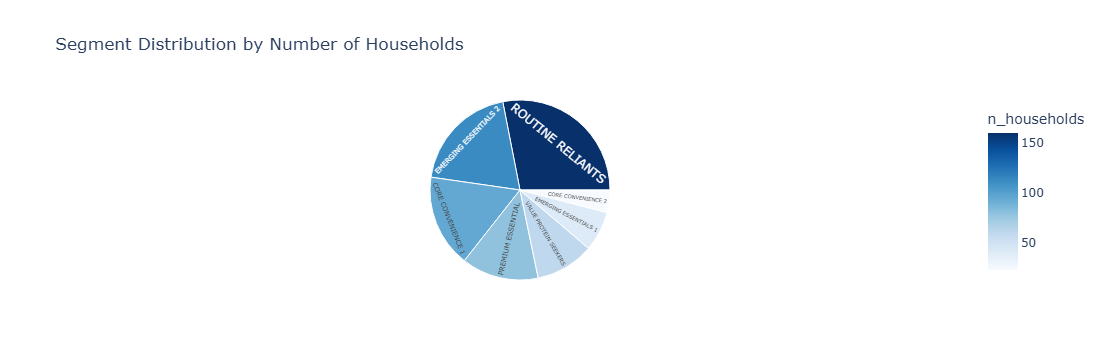

In [94]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("merged_segment_profiles.csv")

segment_mapping = {
    0.0: 'PREMIUM ESSENTIAL',
    1.0: 'CORE CONVENIENCE 2',
    2.0: 'ROUTINE RELIANTS',
    5.0: 'EMERGING ESSENTIALS 1',
    6.0: 'EMERGING ESSENTIALS 2',
    7.0:'VALUE PROTEIN SEEKERS',
    34.0: 'CORE CONVENIENCE 1'
}

df['segment'] = df['segment'].map(segment_mapping).fillna('Unknown')

fig = px.sunburst(
    df,
    path=['segment'],
    values='n_households',
    color='n_households',
    color_continuous_scale='Blues',
    title='Segment Distribution by Number of Households'
)

fig.show()